# Поиск релевантных статей поддержки Avito

## Кратко о решении

Решение сочетает поиск по словам и смыслу, реранк найденных статей и линейную модель. Набор из 50 кандидатов
содержит почти все правильные статьи, поэтому основная задача состоит в точной расстановке близких инструкций.
Текстовые оценки объединяются с кроссфит-признаками из разметки. После выбора параметров линейная модель
повторно обучается на всех запросах из calibration.f.


## Задача и данные

Для каждого запроса нужно вернуть до десяти уникальных `article_id` в порядке релевантности. В данных находятся
793 статьи, 500 размеченных запросов и 500 запросов для формирования ответа. Разметка охватывает 79 статей, причем
40 из них встречаются один раз, поэтому отдельно проверяется качество на редких статьях.


In [1]:
from __future__ import annotations

import gc
import hashlib
import json
import os
import random
import re
import sys
import time
import warnings
from collections import Counter, defaultdict
from dataclasses import asdict, dataclass, field
from pathlib import Path
from typing import Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from bs4 import BeautifulSoup, Tag
from IPython.display import Markdown, display
from rank_bm25 import BM25Okapi
from scipy.sparse import csr_matrix, load_npz, save_npz
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.auto import tqdm

ROOT = Path.cwd()
DATA_DIR = ROOT / "candidate_data"
ARTIFACTS = Path(os.getenv("AVITO_ARTIFACTS_DIR", ROOT / "artifacts"))
MODEL_CACHE = Path(os.getenv("AVITO_MODEL_CACHE_DIR", ROOT / ".cache" / "models"))
LEGACY_MODEL_CACHE = ARTIFACTS / "models" / "huggingface"
FORCE_RECOMPUTE = os.getenv("AVITO_FORCE_RECOMPUTE", "0") == "1"
DEVICE = os.getenv("AVITO_DEVICE", "auto")
RANDOM_SEED = 42
SECTION_TIMES: dict[str, float] = {}

required_data = [DATA_DIR / name for name in ("articles.f", "calibration.f", "test.f")]
missing = [str(path) for path in required_data if not path.exists()]
if missing:
    raise FileNotFoundError("Не найдены исходные файлы:\n" + "\n".join(missing))
ARTIFACTS.mkdir(parents=True, exist_ok=True)
MODEL_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("HF_HOME", str(MODEL_CACHE))
warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 110)
pd.set_option("display.float_format", lambda value: f"{value:.6f}")

try:
    import torch
except ImportError as error:
    raise ImportError("Сначала установите PyTorch и зависимости по README.md") from error

detected_device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Python {sys.version.split()[0]} | PyTorch {torch.__version__} | device={detected_device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))


Python 3.11.9 | PyTorch 2.10.0+cu128 | device=cuda
NVIDIA GeForce RTX 5060 Laptop GPU


### Модели



In [2]:
PREPROCESSING_VERSION = "html-v1"
PARAMETER_LIMIT = 1_000_000_000


@dataclass(frozen=True)
class ModelSpec:
    model_id: str
    revision: str
    parameter_count: int
    cache_version: str


QWEN_EMBEDDING_SPEC = ModelSpec(
    "Qwen/Qwen3-Embedding-0.6B", "97b0c614be4d77ee51c0cef4e5f07c00f9eb65b3", 595776512, "qwen-embedding-v2"
)
BGE_M3_SPEC = ModelSpec("BAAI/bge-m3", "c01c5b303a87da9c91d581256f0af47b5e0a9bd1", 568805377, "bge-m3-dense-sparse-v2")
BGE_RERANKER_SPEC = ModelSpec(
    "BAAI/bge-reranker-v2-m3", "953dc6f6f85a1b2dbfca4c34a2796e7dde08d41e", 567755777, "bge-reranker-v2"
)
QWEN_RERANKER_SPEC = ModelSpec(
    "Qwen/Qwen3-Reranker-0.6B", "e61197ed45024b0ed8a2d74b80b4d909f1255473", 596000000, "qwen3-reranker-pair-v1"
)

QWEN_MODEL, QWEN_REVISION = QWEN_EMBEDDING_SPEC.model_id, QWEN_EMBEDDING_SPEC.revision
QWEN_PARAMETER_COUNT, QWEN_CACHE_VERSION = (QWEN_EMBEDDING_SPEC.parameter_count, QWEN_EMBEDDING_SPEC.cache_version)
BGE_M3_MODEL, BGE_M3_REVISION = BGE_M3_SPEC.model_id, BGE_M3_SPEC.revision
BGE_M3_PARAMETER_COUNT, BGE_M3_CACHE_VERSION = BGE_M3_SPEC.parameter_count, BGE_M3_SPEC.cache_version
BGE_RERANKER_MODEL, BGE_RERANKER_REVISION = BGE_RERANKER_SPEC.model_id, BGE_RERANKER_SPEC.revision
BGE_RERANKER_PARAMETER_COUNT, BGE_RERANKER_CACHE_VERSION = (
    BGE_RERANKER_SPEC.parameter_count,
    BGE_RERANKER_SPEC.cache_version,
)
QWEN_RERANKER_MODEL, QWEN_RERANKER_REVISION = QWEN_RERANKER_SPEC.model_id, QWEN_RERANKER_SPEC.revision
QWEN_RERANKER_PARAMETER_COUNT = QWEN_RERANKER_SPEC.parameter_count

QWEN_QUERY_TASK = (
    "Given a short Russian customer-support query, retrieve Avito help-center passages that contain "
    "the information needed to answer it. Multiple passages may be relevant."
)
PROTOTYPE_CACHE_VERSION = 2
FINAL_CACHE_VERSION = "final-rrf-rankings-v1"
FINAL_PIPELINE_ID = "qwen-bge-c01c5-logreg-rrf-k30"
FINAL_CONFIG_IDENTIFIERS = {
    "qwen_model": QWEN_MODEL,
    "qwen_revision": QWEN_REVISION,
    "bge_m3_model": BGE_M3_MODEL,
    "bge_m3_revision": BGE_M3_REVISION,
    "reranker_model": BGE_RERANKER_MODEL,
    "reranker_revision": BGE_RERANKER_REVISION,
    "preprocessing_version": PREPROCESSING_VERSION,
    "qwen_cache_version": QWEN_CACHE_VERSION,
    "bge_m3_cache_version": BGE_M3_CACHE_VERSION,
    "reranker_cache_version": BGE_RERANKER_CACHE_VERSION,
    "chunk_strategy": "qwen_dense_2",
}
ARTICLE_COLUMNS = ["article_id", "title", "body"]
CALIBRATION_COLUMNS = ["query_id", "query_text", "ground_truth"]
TEST_COLUMNS = ["query_id", "query_text"]
TOKEN_RE = re.compile(r"[a-zа-яё0-9]+", re.IGNORECASE)
ARTICLE_LINK_RE = re.compile(r"(?:https?://support\.avito\.ru)?/articles/(\d+)")
SPACE_RE = re.compile(r"[ \t\f\v]+")
BLANK_LINES_RE = re.compile(r"\n{3,}")


In [3]:
@dataclass
class ProcessedArticle:
    article_id: int
    clean_title: str
    clean_full_text: str
    headings: list[str]
    paragraphs: list[str]
    list_items: list[str]
    table_text: list[str]
    tab_titles: list[str]
    spoiler_titles: list[str]
    anchor_text: list[str]
    linked_article_ids: list[int]
    structured_chunks: list[str]
    anchor_links: list[dict[str, object]] = field(default_factory=list)

    @property
    def plain_text(self) -> str:
        return normalize_text(f"{self.clean_title}\n{self.clean_full_text}")

    def to_dict(self) -> dict[str, object]:
        return asdict(self)


@dataclass
class PredictionResult:
    rankings: list[list[int]]
    runtime_seconds: float
    peak_vram_mb: float
    metadata: dict[str, object]


In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    try:
        import torch

        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except ImportError:
        pass


def select_device(requested: str = "auto") -> str:
    import torch

    if requested == "auto":
        return "cuda" if torch.cuda.is_available() else "cpu"
    if requested == "cuda" and not torch.cuda.is_available():
        raise RuntimeError("CUDA requested but torch.cuda.is_available() is False")
    if requested not in {"cpu", "cuda"}:
        raise ValueError("device must be auto, cpu, or cuda")
    return requested


def count_and_validate_parameters(model: object, model_name: str) -> int:
    number_of_parameters = sum(int(parameter.numel()) for parameter in model.parameters())
    if number_of_parameters >= PARAMETER_LIMIT:
        raise RuntimeError(
            f"{model_name} has {number_of_parameters:,} parameters; "
            f"the task requires strictly fewer than {PARAMETER_LIMIT:,}."
        )
    return number_of_parameters


def release_model(model: object | None = None) -> None:
    import torch

    if model is not None:
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def hash_texts(texts: Sequence[str]) -> str:
    digest = hashlib.sha256()
    for text in texts:
        encoded = str(text).encode("utf-8")
        digest.update(len(encoded).to_bytes(8, "little"))
        digest.update(encoded)
    return digest.hexdigest()


resolved_device = select_device(DEVICE)


In [5]:
def validate_final_config(config: dict[str, object]) -> None:
    if config.get("frozen_final") is not True:
        raise ValueError("Final config must contain frozen_final=True")
    for key, expected in FINAL_CONFIG_IDENTIFIERS.items():
        if config.get(key) != expected:
            raise ValueError(f"Final config mismatch for {key}: {config.get(key)!r} != {expected!r}")
    if config.get("device") not in {"cpu", "cuda"}:
        raise ValueError("Final config device must already be resolved")
    if int(config.get("candidate_top_n", 0)) != 50:
        raise ValueError("Final config must use the evaluated top-50 candidate pool")
    if config.get("ranking_objective") != "pointwise-linear-rrf-v1":
        raise ValueError("Final config must use the selected pointwise objective")
    if config.get("finalization_mode") != "full_refit":
        raise ValueError("Final config must use full-data refit")
    selection = config.get("global_selection")
    required = {"neighbor_k", "C", "rrf_weight"}
    if not isinstance(selection, dict) or not required.issubset(selection):
        raise ValueError("Final config must contain the inner-split selection")


In [6]:
def stable_hash(value: object) -> str:
    """Хэширует детерминированное JSON-представление объекта."""

    def normalize(item: object) -> object:
        if isinstance(item, dict):
            return {str(key): normalize(inner) for key, inner in sorted(item.items(), key=lambda pair: str(pair[0]))}
        if isinstance(item, (list, tuple)):
            return [normalize(inner) for inner in item]
        if isinstance(item, np.ndarray):
            return normalize(item.tolist())
        if isinstance(item, (np.integer,)):
            return int(item)
        if isinstance(item, (np.floating,)):
            return float(item)
        if isinstance(item, Path):
            return item.as_posix()
        return item

    payload = json.dumps(normalize(value), ensure_ascii=False, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return hashlib.sha256(payload).hexdigest()


def cache_metadata_matches(
    actual: dict[str, object], expected: dict[str, object], *, matrix: np.ndarray | None = None
) -> bool:
    """Проверяет metadata и физические свойства матрицы без неявных допущений."""
    if any(actual.get(key) != value for key, value in expected.items()):
        return False
    if matrix is None:
        return True
    return actual.get("matrix_shape") == list(matrix.shape) and actual.get("dtype") == str(matrix.dtype)


def load_array_cache(array_path: Path, expected_metadata: dict[str, object]) -> np.ndarray | None:
    """Загружает массив только при полном совпадении metadata, shape и dtype."""
    if FORCE_RECOMPUTE:
        return None
    metadata_path = array_path.with_suffix(".json")
    if not array_path.exists() or not metadata_path.exists():
        return None
    try:
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        matrix = np.load(array_path, allow_pickle=False)
    except (OSError, ValueError, json.JSONDecodeError):
        return None
    if not cache_metadata_matches(metadata, expected_metadata, matrix=matrix):
        return None
    return matrix


def save_array_cache(array_path: Path, matrix: np.ndarray, metadata: dict[str, object]) -> None:
    """Сохраняет массив и полную metadata совместимости."""
    array_path.parent.mkdir(parents=True, exist_ok=True)
    matrix = np.asarray(matrix)
    np.save(array_path, matrix)
    payload = {**metadata, "matrix_shape": list(matrix.shape), "dtype": str(matrix.dtype)}
    array_path.with_suffix(".json").write_text(
        json.dumps(payload, ensure_ascii=False, sort_keys=True, indent=2), encoding="utf-8"
    )


## Валидация

Используются пять мультилейбл-стратифицированных фолдов с `seed=42`. Признаки из разметки строятся отдельно внутри
каждого внешнего фолда, а параметры модели выбираются на внутреннем сплите. 


In [7]:
def _read_feather(path: Path, expected_columns: list[str]) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required file is missing: {path}")
    frame = pd.read_feather(path)
    if list(frame.columns) != expected_columns:
        raise ValueError(f"Invalid schema for {path.name}: {list(frame.columns)}; expected {expected_columns}")
    if frame.isna().any().any():
        raise ValueError(f"{path.name} contains missing values")
    return frame


def load_articles(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    frame = _read_feather(data_dir / "articles.f", ARTICLE_COLUMNS).copy()
    frame["article_id"] = frame["article_id"].astype(np.int64)
    if frame["article_id"].duplicated().any():
        raise ValueError("articles.f contains duplicate article_id")
    return frame


def parse_article_ids(value: str | Iterable[int]) -> tuple[int, ...]:
    values = (
        tuple(int(part) for part in value.split()) if isinstance(value, str) else tuple(int(part) for part in value)
    )
    if not values:
        raise ValueError("ground_truth must not be empty")
    if len(values) != len(set(values)):
        raise ValueError("ground_truth contains duplicate article_id")
    return values


def load_calibration(data_dir: Path = DATA_DIR, valid_article_ids: set[int] | None = None) -> pd.DataFrame:
    frame = _read_feather(data_dir / "calibration.f", CALIBRATION_COLUMNS).copy()
    frame["query_id"] = frame["query_id"].astype(np.int64)
    frame["relevant_ids"] = frame["ground_truth"].map(parse_article_ids)
    if frame["query_id"].duplicated().any():
        raise ValueError("calibration.f contains duplicate query_id")
    if valid_article_ids is not None:
        unknown = sorted(
            {article_id for row in frame["relevant_ids"] for article_id in row if article_id not in valid_article_ids}
        )
        if unknown:
            raise ValueError(f"Unknown ground-truth article IDs: {unknown}")
    return frame


def load_test(data_dir: Path = DATA_DIR) -> pd.DataFrame:
    """Load test data without logging or displaying query text."""
    frame = _read_feather(data_dir / "test.f", TEST_COLUMNS).copy()
    frame["query_id"] = frame["query_id"].astype(np.int64)
    if frame["query_id"].duplicated().any():
        raise ValueError("test.f contains duplicate query_id")
    return frame


In [8]:
def assign_multilabel_folds(calibration: pd.DataFrame, *, n_splits: int = 5, seed: int = 42) -> np.ndarray:
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
    from sklearn.preprocessing import MultiLabelBinarizer

    labels = calibration["relevant_ids"].tolist()
    classes = sorted({article_id for row in labels for article_id in row})
    targets = MultiLabelBinarizer(classes=classes).fit_transform(labels)
    splitter = MultilabelStratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_ids = np.full(len(calibration), -1, dtype=np.int64)
    dummy = np.zeros((len(calibration), 1), dtype=np.float32)
    for fold_id, (_, validation_indices) in enumerate(splitter.split(dummy, targets)):
        fold_ids[validation_indices] = fold_id
    if (fold_ids < 0).any():
        raise RuntimeError("not every calibration row received a fold")
    return fold_ids


In [9]:
seed_everything(RANDOM_SEED)
articles = load_articles().sort_values("article_id", kind="stable").reset_index(drop=True)
valid_article_ids = set(articles["article_id"].astype(int))
calibration = load_calibration(valid_article_ids=valid_article_ids)
article_ids = articles["article_id"].to_numpy(dtype=np.int64)
queries = calibration["query_text"].astype(str).tolist()
labels = calibration["relevant_ids"].tolist()
fold_ids = assign_multilabel_folds(calibration, n_splits=5, seed=RANDOM_SEED)
title_by_id = dict(zip(articles["article_id"].astype(int), articles["title"].astype(str)))
data_audit = pd.DataFrame(
    [
        {
            "file": name,
            "rows": len(frame),
            "columns": ", ".join(frame.columns),
            "missing_cells": int(frame.isna().sum().sum()),
        }
        for name, frame in (("articles.f", articles), ("calibration.f", calibration))
    ]
)
display(data_audit)
display(pd.DataFrame({"fold": fold_ids}).value_counts().rename("queries").reset_index())


,file,rows,columns,missing_cells
0,articles.f,793,"article_id, title, body",0
1,calibration.f,500,"query_id, query_text, ground_truth, relevant_ids",0


,fold,queries
0,4,102
1,3,101
2,1,101
3,2,100
4,0,96


### Метрики



In [10]:
def _validate_prediction(prediction: Sequence[int]) -> list[int]:
    values = [int(value) for value in prediction]
    if len(values) != len(set(values)):
        raise ValueError("prediction contains duplicate article_id")
    return values


def average_precision_at_k(prediction: Sequence[int], relevant: Sequence[int] | set[int], k: int = 10) -> float:
    if k <= 0:
        raise ValueError("k must be positive")
    ranked = _validate_prediction(prediction)[:k]
    relevant_set = {int(value) for value in relevant}
    if not relevant_set:
        return 0.0
    hits = 0
    score = 0.0
    for rank, article_id in enumerate(ranked, start=1):
        if article_id in relevant_set:
            hits += 1
            score += hits / rank
    return score / min(len(relevant_set), k)


def mean_average_precision_at_k(
    predictions: Sequence[Sequence[int]], ground_truth: Sequence[Sequence[int] | set[int]], k: int = 10
) -> float:
    if len(predictions) != len(ground_truth) or not predictions:
        raise ValueError("predictions and ground_truth must have equal non-zero length")
    return float(
        np.mean(
            [average_precision_at_k(prediction, relevant, k) for prediction, relevant in zip(predictions, ground_truth)]
        )
    )


def recall_at_k(prediction: Sequence[int], relevant: Sequence[int] | set[int], k: int) -> float:
    ranked = _validate_prediction(prediction)[:k]
    relevant_set = {int(value) for value in relevant}
    return 0.0 if not relevant_set else len(set(ranked) & relevant_set) / len(relevant_set)


def paired_bootstrap_map_ci(
    candidate_rankings: Sequence[Sequence[int]],
    reference_rankings: Sequence[Sequence[int]],
    ground_truth: Sequence[Sequence[int] | set[int]],
    *,
    samples: int = 10_000,
    seed: int = 42,
) -> tuple[float, float]:
    candidate_ap = np.asarray(
        [average_precision_at_k(ranking, relevant, 10) for ranking, relevant in zip(candidate_rankings, ground_truth)]
    )
    reference_ap = np.asarray(
        [average_precision_at_k(ranking, relevant, 10) for ranking, relevant in zip(reference_rankings, ground_truth)]
    )
    differences = candidate_ap - reference_ap
    rng = np.random.default_rng(seed)
    sample_indices = rng.integers(0, len(differences), size=(samples, len(differences)))
    bootstrap_means = differences[sample_indices].mean(axis=1)
    low, high = np.quantile(bootstrap_means, [0.025, 0.975])
    return float(low), float(high)


In [11]:
def rankings_from_scores(scores: np.ndarray, article_ids: np.ndarray, top_k: int = 50) -> list[list[int]]:
    if scores.ndim != 2 or scores.shape[1] != len(article_ids):
        raise ValueError("score matrix and article_ids have incompatible shapes")
    tie_break = np.asarray(article_ids, dtype=np.int64)
    return [[int(article_ids[index]) for index in np.lexsort((tie_break, -np.asarray(row)))[:top_k]] for row in scores]


def evaluate_rankings(
    rankings: Sequence[Sequence[int]], ground_truth: Sequence[Sequence[int] | set[int]]
) -> dict[str, float]:
    metrics = {f"MAP@{k}": mean_average_precision_at_k(rankings, ground_truth, k) for k in (1, 3, 5, 10)}
    metrics["Recall@10"] = float(
        np.mean([recall_at_k(ranking, relevant, 10) for ranking, relevant in zip(rankings, ground_truth)])
    )
    for k in (30, 50):
        metrics[f"candidate_recall@{k}"] = float(
            np.mean([recall_at_k(ranking, relevant, k) for ranking, relevant in zip(rankings, ground_truth)])
        )
    return metrics


def row_minmax(scores: np.ndarray) -> np.ndarray:
    values = np.asarray(scores, dtype=np.float32)
    low = values.min(axis=1, keepdims=True)
    high = values.max(axis=1, keepdims=True)
    scale = high - low
    return np.divide(values - low, scale, out=np.zeros_like(values), where=scale > 1e-12)


def tokenize(text: str) -> list[str]:
    return TOKEN_RE.findall(str(text).lower())


def _tfidf_scores(
    documents: list[str],
    queries: list[str],
    *,
    analyzer: str,
    ngram_range: tuple[int, int],
    min_df: int,
    max_features: int | None,
) -> np.ndarray:
    vectorizer = TfidfVectorizer(
        analyzer=analyzer,
        ngram_range=ngram_range,
        min_df=min_df,
        sublinear_tf=True,
        norm="l2",
        lowercase=True,
        dtype=np.float32,
        max_features=max_features,
        token_pattern=r"(?u)\b[\w-]{2,}\b" if analyzer == "word" else None,
    )
    document_matrix = vectorizer.fit_transform(documents)
    query_matrix = vectorizer.transform(queries)
    return (query_matrix @ document_matrix.T).toarray().astype(np.float32)


In [12]:
def aggregate_chunk_similarity(
    query_embeddings, chunk_embeddings, chunk_article_ids: np.ndarray, article_ids: np.ndarray
) -> np.ndarray:
    similarities = query_embeddings @ chunk_embeddings.T
    if hasattr(similarities, "toarray"):
        similarities = similarities.toarray()
    output = np.zeros((query_embeddings.shape[0], len(article_ids)), dtype=np.float32)
    for article_index, article_id in enumerate(article_ids):
        indices = np.flatnonzero(chunk_article_ids == article_id)
        output[:, article_index] = similarities[:, indices].max(axis=1)
    return output


In [13]:
example_prediction = [10, 20, 30, 40]
example_relevant = [20, 40]
metric_example = pd.DataFrame(
    {
        "Позиция": [1, 2, 3, 4],
        "article_id": example_prediction,
        "Релевантна": [value in example_relevant for value in example_prediction],
        "Precision на позиции": [0.0, 1 / 2, 0.0, 2 / 4],
    }
)
display(metric_example)
print("AP@10 числового примера:", average_precision_at_k(example_prediction, example_relevant, 10))

assert average_precision_at_k([7], [7], 10) == 1.0
assert np.isclose(average_precision_at_k([7, 9, 8], [7, 8], 10), (1.0 + 2 / 3) / 2)
assert np.isclose(average_precision_at_k([9, 7], [7, 8], 10), 0.25)
assert np.isclose(average_precision_at_k([7], [7, 8], 10), 0.5)
try:
    average_precision_at_k([7, 7], [7], 10)
except ValueError:
    pass
else:
    raise AssertionError("Дубликаты article_id должны отклоняться")


,Позиция,article_id,Релевантна,Precision на позиции
0,1,10,False,0.000000
1,2,20,True,0.500000
2,3,30,False,0.000000
3,4,40,True,0.500000


AP@10 числового примера: 0.5


In [14]:
fold_table = pd.DataFrame({"fold": fold_ids, "Правильных статей": calibration["relevant_ids"].map(len)}).groupby("fold")
fold_table = (
    fold_table
    .agg(**{"Validation-запросов": ("fold", "size"), "Среднее число правильных статей": ("Правильных статей", "mean")})
    .reset_index()
)
display(fold_table)


,fold,Validation-запросов,Среднее число правильных статей
0,0,96,1.572917
1,1,101,1.524752
2,2,100,1.540000
3,3,101,1.485149
4,4,102,1.490196


## Обработка HTML

Из статьи извлекаются заголовки, абзацы, списки, таблицы, вкладки, спойлеры и внутренние ссылки. Помимо полного
текста создаются короткие смысловые фрагменты, чтобы модель могла найти конкретную инструкцию внутри длинной
страницы.


In [15]:
def normalize_text(text: str) -> str:
    lines = []
    for line in str(text).replace("\r\n", "\n").replace("\r", "\n").split("\n"):
        cleaned = SPACE_RE.sub(" ", line).strip()
        if cleaned:
            lines.append(cleaned)
    return BLANK_LINES_RE.sub("\n\n", "\n".join(lines)).strip()


def _unique_nonempty(values: list[str]) -> list[str]:
    seen: set[str] = set()
    output: list[str] = []
    for value in values:
        cleaned = normalize_text(value)
        if cleaned and cleaned not in seen:
            seen.add(cleaned)
            output.append(cleaned)
    return output


def _visible_soup(html: str) -> BeautifulSoup:
    soup = BeautifulSoup(html or "", "lxml")
    for tag in soup.find_all(["script", "style", "noscript", "template", "svg", "input"]):
        tag.decompose()
    for tag in soup.find_all(True):
        style = str(tag.get("style", "")).replace(" ", "").lower()
        if tag.has_attr("hidden") or "display:none" in style or "visibility:hidden" in style:
            tag.decompose()
    return soup


def _class_contains(tag: Tag, fragment: str) -> bool:
    return any(fragment in str(value).lower() for value in (tag.get("class") or []))


In [16]:
def _section_blocks(soup: BeautifulSoup) -> list[tuple[str, str]]:
    sections: list[tuple[str, list[str]]] = [("Введение", [])]
    heading_names = {"h1", "h2", "h3", "h4", "h5", "h6", "headline"}
    block_names = {"p", "li", "tr", "label"}
    for tag in soup.find_all([*heading_names, *block_names]):
        if tag.name in heading_names:
            heading = normalize_text(tag.get_text(" ", strip=True))
            if heading:
                sections.append((heading, []))
            continue
        if tag.name == "p" and tag.find_parent(["li", "td", "th"]):
            continue
        if tag.name in {"li", "tr"} and tag.find_parent(tag.name):
            continue
        if tag.name == "label" and not (_class_contains(tag, "tab-label") or _class_contains(tag, "spoiler-title")):
            continue
        value = normalize_text(tag.get_text(" ", strip=True))
        if value and (not sections[-1][1] or sections[-1][1][-1] != value):
            sections[-1][1].append(value)
    return [(name, "\n".join(values)) for name, values in sections if values]


def _split_long_block(text: str, max_chars: int, overlap: int) -> list[str]:
    if len(text) <= max_chars:
        return [text]
    chunks: list[str] = []
    start = 0
    while start < len(text):
        end = min(start + max_chars, len(text))
        if end < len(text):
            boundary = max(
                (text.rfind(separator, start + max_chars // 2, end) for separator in ("\n", ". ", "! ", "? "))
            )
            if boundary > start:
                end = boundary + 1
        chunk = normalize_text(text[start:end])
        if chunk:
            chunks.append(chunk)
        if end >= len(text):
            break
        start = max(start + 1, end - overlap)
    return chunks


def build_structured_chunks(
    title: str, soup: BeautifulSoup, *, max_chars: int = 1800, overlap: int = 180, min_chars: int = 180
) -> list[str]:
    chunks: list[str] = []
    for section, body in _section_blocks(soup):
        for part in _split_long_block(body, max_chars, overlap):
            prefix = f"Title: {title}\nSection: {section}\nText: "
            candidate = normalize_text(prefix + part)
            if len(candidate) < min_chars and chunks:
                combined = normalize_text(chunks[-1] + "\n" + part)
                if len(combined) <= max_chars + len(prefix):
                    chunks[-1] = combined
                    continue
            if candidate:
                chunks.append(candidate)
    if not chunks:
        fallback = normalize_text(soup.get_text("\n", strip=True))
        if fallback:
            chunks = [normalize_text(f"Title: {title}\nSection: Введение\nText: {fallback}")]
    return chunks


In [17]:
def process_article(article_id: int, title: str, html: str) -> ProcessedArticle:
    soup = _visible_soup(str(html))
    clean_title = normalize_text(title)
    headings = _unique_nonempty(
        [tag.get_text(" ", strip=True) for tag in soup.find_all(["h1", "h2", "h3", "h4", "h5", "h6", "headline"])]
    )
    paragraphs = _unique_nonempty([tag.get_text(" ", strip=True) for tag in soup.find_all("p")])
    list_items = _unique_nonempty([tag.get_text(" ", strip=True) for tag in soup.find_all("li")])
    table_text = _unique_nonempty(
        [
            " | ".join((cell.get_text(" ", strip=True) for cell in row.find_all(["th", "td"])))
            for row in soup.find_all("tr")
        ]
    )
    tab_titles = _unique_nonempty(
        [
            tag.get_text(" ", strip=True)
            for tag in soup.find_all(class_=lambda value: value and "tab-label" in str(value))
        ]
    )
    spoiler_titles = _unique_nonempty(
        [
            tag.get_text(" ", strip=True)
            for tag in soup.find_all(class_=lambda value: value and "spoiler-title" in str(value))
        ]
    )
    anchors = soup.find_all("a", href=True)
    anchor_text = _unique_nonempty([tag.get_text(" ", strip=True) for tag in anchors])
    linked_ids = sorted(
        {int(match.group(1)) for tag in anchors if (match := ARTICLE_LINK_RE.search(str(tag.get("href", ""))))}
    )
    anchor_links: list[dict[str, object]] = []
    current_section = clean_title
    for tag in soup.find_all(True):
        if tag.name in {"h1", "h2", "h3", "h4", "h5", "h6"}:
            current_section = normalize_text(tag.get_text(" ", strip=True)) or clean_title
        if tag.name != "a" or not tag.get("href"):
            continue
        match = ARTICLE_LINK_RE.search(str(tag.get("href")))
        text = normalize_text(tag.get_text(" ", strip=True))
        if match is None or not text:
            continue
        parent_text = normalize_text(tag.parent.get_text(" ", strip=True)) if tag.parent else text
        anchor_links.append(
            {
                "source_article_id": int(article_id),
                "target_article_id": int(match.group(1)),
                "anchor_text": text,
                "section_title": current_section,
                "surrounding_text": parent_text,
            }
        )
    return ProcessedArticle(
        article_id=int(article_id),
        clean_title=clean_title,
        clean_full_text=normalize_text(soup.get_text("\n", strip=True)),
        headings=headings,
        paragraphs=paragraphs,
        list_items=list_items,
        table_text=table_text,
        tab_titles=tab_titles,
        spoiler_titles=spoiler_titles,
        anchor_text=anchor_text,
        linked_article_ids=linked_ids,
        structured_chunks=build_structured_chunks(clean_title, soup),
        anchor_links=anchor_links,
    )


In [18]:
def load_or_process_corpus(articles: pd.DataFrame, data_dir: Path = DATA_DIR) -> list[ProcessedArticle]:
    source_path = data_dir / "articles.f"
    source_hash = hashlib.sha256(source_path.read_bytes()).hexdigest()
    cache_path = ARTIFACTS / "cache" / f"processed_articles_{PREPROCESSING_VERSION}_{source_hash[:12]}.json"
    if cache_path.exists() and not FORCE_RECOMPUTE:
        payload = json.loads(cache_path.read_text(encoding="utf-8"))
        compatible = payload.get("source_hash") == source_hash
        compatible &= payload.get("preprocessing_version") == PREPROCESSING_VERSION
        if compatible:
            return [ProcessedArticle(**row) for row in payload["articles"]]

    documents = [
        process_article(int(row.article_id), str(row.title), str(row.body)) for row in articles.itertuples(index=False)
    ]
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "source_hash": source_hash,
        "preprocessing_version": PREPROCESSING_VERSION,
        "articles": [document.to_dict() for document in documents],
    }
    cache_path.write_text(json.dumps(payload, ensure_ascii=False), encoding="utf-8")
    return documents


In [19]:
documents = load_or_process_corpus(articles)


In [20]:
examples = []
for document in sorted(documents, key=lambda x: len(x.clean_full_text), reverse=True)[:3]:
    examples.append(
        {
            "article_id": document.article_id,
            "title": document.clean_title,
            "headings": document.headings[:4],
            "chunks": len(document.structured_chunks),
            "first_chunk": document.structured_chunks[0][:450],
            "linked_articles": document.linked_article_ids[:8],
        }
    )
display(pd.DataFrame(examples))


,article_id,title,headings,chunks,first_chunk,linked_articles
0,2924,Какими товарами интересуются покупатели,[],315,Title: Какими товарами интересуются покупатели\nSection: Введение\nText: Мы изучили запросы пользователей ...,[]
1,4436,Уровень сервиса,"[Уровень сервиса в Транспорте, Какие бывают уровни, Какие могут быть преимущества и ограничения, Как счита...",78,"Title: Уровень сервиса\nSection: Уровень сервиса в Транспорте\nText: Уровень сервиса — раздел для тех, кто...","[2239, 2244, 2330, 2680, 2707, 3012, 3220, 3273]"
2,4321,Мой уровень сервиса,"[Уровень сервиса в Товарах, Какие бывают уровни, Какие могут быть преимущества и ограничения, Как считаетс...",78,Title: Мой уровень сервиса\nSection: Уровень сервиса в Товарах\nText: Уровень сервиса — раздел для продавц...,"[2239, 2244, 2330, 2680, 2707, 3012, 3220, 3273]"


,Показатель,Значение
0,Число статей,793
1,Число calibration-запросов,500
2,Медианная длина запроса,69
3,Медианная длина HTML,3513
4,Медианная длина очищенной статьи,2275
5,Число разных правильных article_id,79


,Число запросов
Правильных статей,
1,279
2,182
3,38
4,1


,query_id,query_text,ground_truth,Названия правильных статей
0,1,Как передать товар через службу авито,"(1909, 4234)","[Отправить заказ, Как продавать и покупать с доставкой]"
1,2,"Можете подсказать, если заказать товар Авито доставкой и оплатить также через авито, в случае возврата тов...","(2865, 4400)","[Когда вернутся деньги за доставку, Покупателю — отказаться от товара или вернуть его]"
2,3,Здравствуйте. Как отправить товар через Авито.,"(1909,)",[Отправить заказ]
3,4,как получить деньги за возрат если продавец уже забрал товар?,"(4400, 4403)","[Покупателю — отказаться от товара или вернуть его, Продавцу — товар не забирают или вернули]"
4,5,"Когда мне прийдут деньги за доставку, сегодня уже <DATE>","(4361,)",[Продавцу]


,Частота в calibration
article_id,
4219,129
1951,73
4234,63
2646,57
4328,39
4400,33
4214,31
4384,26
4440,26


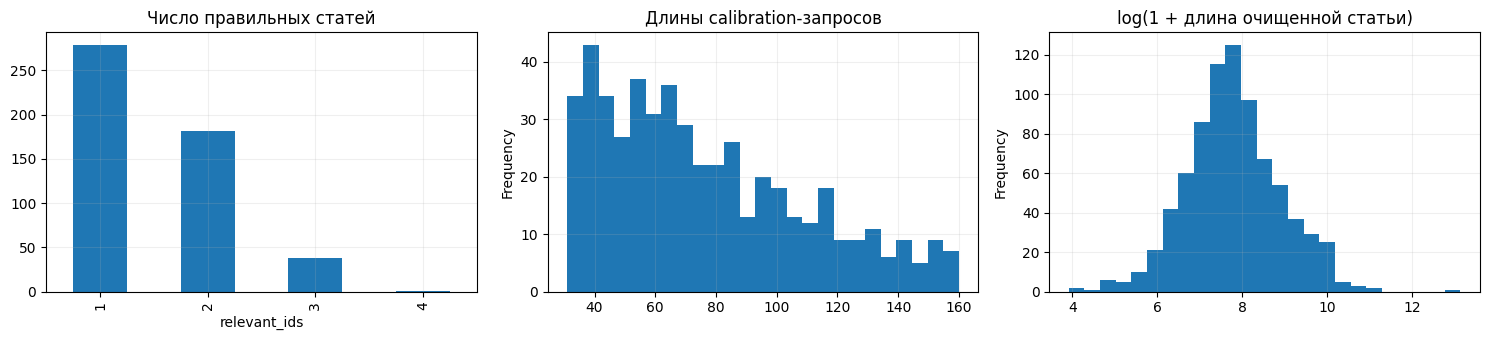

In [21]:
label_counts = calibration["relevant_ids"].map(len)
query_lengths = calibration["query_text"].astype(str).str.len()
html_lengths = articles["body"].astype(str).str.len()
clean_lengths = pd.Series([len(document.plain_text) for document in documents])
label_frequencies = Counter(article_id for row in labels for article_id in row)

data_summary = pd.DataFrame(
    {
        "Показатель": [
            "Число статей",
            "Число calibration-запросов",
            "Медианная длина запроса",
            "Медианная длина HTML",
            "Медианная длина очищенной статьи",
            "Число разных правильных article_id",
        ],
        "Значение": [
            len(articles),
            len(calibration),
            int(query_lengths.median()),
            int(html_lengths.median()),
            int(clean_lengths.median()),
            len(label_frequencies),
        ],
    }
)
display(data_summary)
display(label_counts.value_counts().sort_index().rename_axis("Правильных статей").rename("Число запросов").to_frame())
display(
    pd.DataFrame(
        {
            "query_id": calibration["query_id"].head(5),
            "query_text": calibration["query_text"].head(5),
            "ground_truth": calibration["relevant_ids"].head(5),
            "Названия правильных статей": [
                [title_by_id[int(article_id)] for article_id in row] for row in calibration["relevant_ids"].head(5)
            ],
        }
    )
)
top_labels = pd.Series(label_frequencies).sort_values(ascending=False).head(10)
display(top_labels.rename_axis("article_id").rename("Частота в calibration").to_frame())
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
label_counts.value_counts().sort_index().plot.bar(ax=axes[0], title="Число правильных статей")
query_lengths.plot.hist(ax=axes[1], bins=25, title="Длины calibration-запросов")
np.log1p(clean_lengths).plot.hist(ax=axes[2], bins=25, title="log(1 + длина очищенной статьи)")
for axis in axes:
    axis.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [22]:
html_examples = []
for row, document in zip(articles.head(3).itertuples(index=False), documents[:3]):
    html_examples.append(
        {
            "article_id": int(row.article_id),
            "HTML-фрагмент": str(row.body)[:240],
            "Очищенный текст": document.plain_text[:300],
            "Заголовки": document.headings[:4],
            "Списки и таблицы": (document.list_items + document.table_text)[:4],
            "Тексты ссылок": document.anchor_text[:4],
            "Chunks": document.structured_chunks[:2],
        }
    )
display(pd.DataFrame(html_examples))


,article_id,HTML-фрагмент,Очищенный текст,Заголовки,Списки и таблицы,Тексты ссылок,Chunks
0,1730,"<ol><li><p>Зайдите в раздел <a href=""https://www.avito.ru/profile/extended"">Управление профилем</a>.</p><o...",Имя или название компании\nЗайдите в раздел\nУправление профилем\n.\nНажмите\nна карандашик\nв правом верх...,[],[Зайдите в раздел Управление профилем . Нажмите на карандашик в правом верхнем углу. Введите новое имя или...,"[Управление профилем, напишите нам, профессиональный профиль]",[Title: Имя или название компании\nSection: Введение\nText: Зайдите в раздел Управление профилем . Нажмите...
1,1746,"<p>Проверьте, какое сообщение вы видите при входе в профиль.</p><div class=""tabset tabset_155""><input type...","Понять, что профиль заблокирован\nПроверьте, какое сообщение вы видите при входе в профиль.\nПрофиль забло...",[],"[Если это «Мы заметили в нём признаки взлома» или «В нём замечены признаки взлома», напишите нам — провери...","[причины блокировки, Ваши объявления могли вводить покупателей в заблуждение, У вас есть другой профиль с ...","[Title: Понять, что профиль заблокирован\nSection: Введение\nText: Проверьте, какое сообщение вы видите пр..."
2,1747,<ol><li><p><strong>Не заводите несколько аккаунтов для продаж в одной категории. </strong>Так поступают по...,Не допустить блокировки профиля\nНе заводите несколько аккаунтов для продаж в одной категории.\nТак поступ...,"[Что делать, если профиль заблокировали]","[Не заводите несколько аккаунтов для продаж в одной категории. Так поступают пользователи, которые хотят о...","[свяжите их, Ваши объявления могли вводить покупателей в заблуждение, У вас есть другой профиль с пройденн...",[Title: Не допустить блокировки профиля\nSection: Введение\nText: Не заводите несколько аккаунтов для прод...


## Лексический и семантический поиск

TF-IDF и BM25 хорошо находят названия кнопок, платежных способов и статусов заказа. Qwen и BGE-M3 дополняют их
поиском близких по смыслу формулировок. Все оценки нормируются отдельно для каждого запроса и объединяются в общий
список кандидатов.


In [23]:
def build_lexical_signals(documents: list[ProcessedArticle], queries: list[str]) -> dict[str, np.ndarray]:
    article_ids = np.asarray([document.article_id for document in documents])
    signals = {
        "word_title": _tfidf_scores(
            [document.clean_title for document in documents],
            queries,
            analyzer="word",
            ngram_range=(1, 2),
            min_df=1,
            max_features=60_000,
        ),
        "word_body": _tfidf_scores(
            [document.plain_text for document in documents],
            queries,
            analyzer="word",
            ngram_range=(1, 2),
            min_df=1,
            max_features=120_000,
        ),
        "char": _tfidf_scores(
            [document.plain_text for document in documents],
            queries,
            analyzer="char_wb",
            ngram_range=(3, 5),
            min_df=2,
            max_features=140_000,
        ),
    }
    corpus_tokens = [tokenize(document.plain_text) for document in documents]
    bm25 = BM25Okapi(corpus_tokens)
    signals["bm25"] = np.vstack([bm25.get_scores(tokenize(query)) for query in queries]).astype(np.float32)
    chunk_texts = [chunk for document in documents for chunk in document.structured_chunks]
    chunk_article_ids = np.asarray(
        [document.article_id for document in documents for _ in document.structured_chunks], dtype=np.int64
    )
    chunk_scores = _tfidf_scores(
        chunk_texts, queries, analyzer="word", ngram_range=(1, 2), min_df=1, max_features=140000
    )
    chunk_max = np.zeros((len(queries), len(article_ids)), dtype=np.float32)
    for article_index, article_id in enumerate(article_ids):
        article_chunk_indices = np.flatnonzero(chunk_article_ids == article_id)
        chunk_max[:, article_index] = chunk_scores[:, article_chunk_indices].max(axis=1)
    signals["chunk_max"] = chunk_max
    return signals


def build_gated_query_knn(
    train_queries: list[str],
    train_labels: list[tuple[int, ...]],
    target_queries: list[str],
    article_ids: np.ndarray,
    *,
    neighbors: int = 10,
    center: float = 0.25,
    temperature: float = 0.05,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    vectorizer = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), min_df=1, sublinear_tf=True, dtype=np.float32, max_features=100_000
    )
    train_matrix = vectorizer.fit_transform(train_queries)
    target_matrix = vectorizer.transform(target_queries)
    similarities = (target_matrix @ train_matrix.T).toarray().astype(np.float32)
    article_to_column = {int(article_id): column for column, article_id in enumerate(article_ids)}
    votes = np.zeros((len(target_queries), len(article_ids)), dtype=np.float32)
    max_similarity = similarities.max(axis=1)
    for target_index, row in enumerate(similarities):
        for neighbor_index in np.argsort(-row, kind="stable")[:neighbors]:
            similarity = float(row[neighbor_index])
            if similarity <= 0:
                continue
            for article_id in train_labels[int(neighbor_index)]:
                votes[target_index, article_to_column[int(article_id)]] += similarity
    gate = 1.0 / (1.0 + np.exp(-np.clip((max_similarity - center) / temperature, -60.0, 60.0)))
    return votes, max_similarity, gate.astype(np.float32)


def build_gated_query_knn_oof(
    queries: list[str],
    labels: list[tuple[int, ...]],
    fold_ids: np.ndarray,
    article_ids: np.ndarray,
    *,
    neighbors: int = 10,
    center: float = 0.25,
    temperature: float = 0.05,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    output = np.zeros((len(queries), len(article_ids)), dtype=np.float32)
    max_similarity = np.zeros(len(queries), dtype=np.float32)
    gates = np.zeros(len(queries), dtype=np.float32)
    indices = np.arange(len(queries))
    for fold_id in sorted(set(fold_ids.tolist())):
        train_indices = indices[fold_ids != fold_id]
        validation_indices = indices[fold_ids == fold_id]
        votes, similarity, gate = build_gated_query_knn(
            [queries[index] for index in train_indices],
            [labels[index] for index in train_indices],
            [queries[index] for index in validation_indices],
            article_ids,
            neighbors=neighbors,
            center=center,
            temperature=temperature,
        )
        output[validation_indices] = votes
        max_similarity[validation_indices] = similarity
        gates[validation_indices] = gate
    return output, max_similarity, gates


### Представления текстов

Модели кодируют полный текст статьи и ее смысловые фрагменты. Оценка по лучшему фрагменту уменьшает влияние общих
разделов страницы. Версия модели и обработки текста входит в метаданные каждого сохраненного массива.


In [24]:
def _find_json_cache(
    root: Path, *, model_name: str, kind: str, text_hash: str, suffix: str, expected: dict[str, object] | None = None
) -> Path | None:
    if FORCE_RECOMPUTE or not root.exists():
        return None
    for metadata_path in root.glob("*.json"):
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        except (json.JSONDecodeError, OSError):
            continue
        compatible = metadata.get("model_name") == model_name
        compatible &= metadata.get("kind") == kind
        compatible &= metadata.get("text_hash") == text_hash
        compatible &= all(metadata.get(key) == value for key, value in (expected or {}).items())
        candidate = metadata_path.with_suffix(suffix)
        if compatible and candidate.exists():
            return candidate
    return None


def resolve_model_snapshot(model_name: str, revision: str) -> Path:
    from huggingface_hub import snapshot_download

    relative = Path(f"models--{model_name.replace('/', '--')}") / "snapshots" / revision
    for root in (MODEL_CACHE, MODEL_CACHE / "huggingface", LEGACY_MODEL_CACHE):
        candidate = root / relative
        if candidate.exists():
            return candidate.resolve()
    downloaded = Path(snapshot_download(repo_id=model_name, revision=revision, cache_dir=MODEL_CACHE))
    resolved = downloaded.resolve()
    if revision not in resolved.parts:
        raise RuntimeError(f"Resolved snapshot does not contain expected commit {revision}: {resolved}")
    return resolved


def _encode_sentence_transformer(
    model: object, texts: list[str], *, batch_size: int, device: str, prompt: str | None = None
) -> tuple[np.ndarray, int]:
    current_batch = batch_size
    while True:
        try:
            kwargs = {
                "batch_size": current_batch,
                "show_progress_bar": True,
                "convert_to_numpy": True,
                "normalize_embeddings": True,
                "device": device,
            }
            if prompt:
                kwargs["prompt"] = prompt
            return np.asarray(model.encode(texts, **kwargs), dtype=np.float32), current_batch
        except RuntimeError as error:
            if "out of memory" not in str(error).lower() or current_batch <= 1:
                raise
            current_batch = max(1, current_batch // 2)
            release_model(None)


In [25]:
def build_qwen_embeddings(
    documents: list[ProcessedArticle],
    queries: list[str],
    *,
    device: str = "auto",
    batch_size: int = 8,
    max_length: int = 512,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, object]]:
    import torch
    from sentence_transformers import SentenceTransformer

    article_texts = [document.plain_text for document in documents]
    chunk_texts = [chunk for document in documents for chunk in document.structured_chunks]
    cache_root = ARTIFACTS / "embeddings"
    requests = {
        "articles": (article_texts, None),
        "chunks": (chunk_texts, None),
        "queries_task_instruction": (queries, f"Instruct: {QWEN_QUERY_TASK}\nQuery:"),
    }
    arrays: dict[str, np.ndarray] = {}
    cache_hits: dict[str, bool] = {}
    missing: list[str] = []
    for kind, (texts, _) in requests.items():
        path = _find_json_cache(
            cache_root,
            model_name=QWEN_MODEL,
            kind=kind,
            text_hash=hash_texts(texts),
            suffix=".npy",
            expected={
                "model_revision": QWEN_REVISION,
                "max_length": max_length,
                "normalization": True,
                "preprocessing_version": PREPROCESSING_VERSION,
                "instruction": QWEN_QUERY_TASK if kind == "queries_task_instruction" else None,
                "cache_version": QWEN_CACHE_VERSION,
            },
        )
        if path:
            try:
                array = np.load(path, allow_pickle=False)
                metadata = json.loads(path.with_suffix(".json").read_text(encoding="utf-8"))
            except (OSError, ValueError, json.JSONDecodeError):
                array = None
                metadata = {}
            physical_match = (
                array is not None
                and array.ndim == 2
                and array.shape[0] == len(texts)
                and metadata.get("matrix_shape") == list(array.shape)
                and metadata.get("dtype") == str(array.dtype)
            )
            if physical_match:
                arrays[kind] = array
                cache_hits[kind] = True
            else:
                missing.append(kind)
                cache_hits[kind] = False
        else:
            missing.append(kind)
            cache_hits[kind] = False

    selected_device = select_device(device)
    peak_vram = 0.0
    parameter_count = QWEN_PARAMETER_COUNT
    if missing:
        if selected_device == "cuda":
            torch.cuda.reset_peak_memory_stats()
        snapshot = resolve_model_snapshot(QWEN_MODEL, QWEN_REVISION)
        model = SentenceTransformer(
            str(snapshot) if snapshot else QWEN_MODEL,
            revision=None if snapshot else QWEN_REVISION,
            device=selected_device,
            model_kwargs={"dtype": (torch.float16 if selected_device == "cuda" else torch.float32)},
            tokenizer_kwargs={"padding_side": "left"},
            cache_folder=str(MODEL_CACHE),
            local_files_only=bool(snapshot),
        )
        model.max_seq_length = max_length
        parameter_count = count_and_validate_parameters(model, QWEN_MODEL)
        for kind in missing:
            texts, prompt = requests[kind]
            array, batch_size = _encode_sentence_transformer(
                model, texts, batch_size=batch_size, device=selected_device, prompt=prompt
            )
            arrays[kind] = array
            metadata = {
                "model_name": QWEN_MODEL,
                "model_revision": QWEN_REVISION,
                "kind": kind,
                "text_hash": hash_texts(texts),
                "max_length": max_length,
                "normalization": True,
                "preprocessing_version": PREPROCESSING_VERSION,
                "instruction": QWEN_QUERY_TASK if prompt else None,
                "cache_version": QWEN_CACHE_VERSION,
                "parameter_count": parameter_count,
                "matrix_shape": list(array.shape),
                "dtype": str(array.dtype),
            }
            key = stable_hash(metadata)
            cache_root.mkdir(parents=True, exist_ok=True)
            np.save(cache_root / f"{key}.npy", array)
            (cache_root / f"{key}.json").write_text(
                json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8"
            )
        peak_vram = float(torch.cuda.max_memory_allocated() / 1024**2) if selected_device == "cuda" else 0.0
        release_model(model)
    return (
        arrays["articles"],
        arrays["chunks"],
        arrays["queries_task_instruction"],
        {
            "model_name": QWEN_MODEL,
            "revision": QWEN_REVISION,
            "parameter_count": parameter_count,
            "device": selected_device,
            "cache_hits": cache_hits,
            "peak_vram_mb": peak_vram,
        },
    )


In [26]:
def _bge_m3_cache_is_compatible(cache_root: Path, kind: str, texts: list[str], *, max_length: int) -> tuple[bool, int]:
    if FORCE_RECOMPUTE:
        return False, 0
    text_hash = hash_texts(texts)
    metadata_path = cache_root / f"{kind}_{text_hash}.json"
    sparse_metadata_path = cache_root / f"sparse_{kind}_{text_hash}.json"
    dense_path = cache_root / f"{kind}_{text_hash}.npy"
    sparse_path = cache_root / f"sparse_{kind}_{text_hash}.npz"
    if not (dense_path.exists() and sparse_path.exists()):
        return False, 0
    try:
        dense_metadata = json.loads(metadata_path.read_text(encoding="utf-8")) if metadata_path.exists() else {}
        sparse_metadata = (
            json.loads(sparse_metadata_path.read_text(encoding="utf-8")) if sparse_metadata_path.exists() else {}
        )
        dense_matrix = np.load(dense_path, allow_pickle=False)
        sparse_matrix = load_npz(sparse_path).tocsr()
    except (OSError, ValueError, json.JSONDecodeError):
        return False, 0
    dense_ok = (
        dense_metadata.get("model_name") == BGE_M3_MODEL
        and dense_metadata.get("kind") == kind
        and dense_metadata.get("text_hash") == text_hash
        and int(dense_metadata.get("max_length", -1)) == max_length
        and dense_metadata.get("normalization") is True
        and dense_metadata.get("preprocessing_version") == PREPROCESSING_VERSION
    )
    revision = dense_metadata.get("model_revision") or sparse_metadata.get("model_revision")
    sparse_ok = (
        sparse_metadata.get("model_name") == BGE_M3_MODEL
        and sparse_metadata.get("kind") == f"sparse_{kind}"
        and sparse_metadata.get("text_hash") == text_hash
        and int(sparse_metadata.get("max_length", -1)) == max_length
        and sparse_metadata.get("cache_version") == BGE_M3_CACHE_VERSION
        and sparse_metadata.get("preprocessing_version") == PREPROCESSING_VERSION
    )
    physical_ok = (
        dense_matrix.ndim == 2
        and dense_matrix.shape[0] == len(texts)
        and sparse_matrix.ndim == 2
        and sparse_matrix.shape[0] == len(texts)
        and dense_metadata.get("matrix_shape") == list(dense_matrix.shape)
        and dense_metadata.get("dtype") == str(dense_matrix.dtype)
        and sparse_metadata.get("matrix_shape") == list(sparse_matrix.shape)
        and sparse_metadata.get("dtype") == str(sparse_matrix.dtype)
    )
    if not (dense_ok and sparse_ok and physical_ok and revision == BGE_M3_REVISION):
        return False, 0
    cached_version = dense_metadata.get("cache_version")
    if cached_version != BGE_M3_CACHE_VERSION:
        return False, 0
    parameter_count = int(dense_metadata.get("parameter_count", BGE_M3_PARAMETER_COUNT))
    return True, parameter_count


def lexical_weights_to_csr(rows: list[dict[str, float]], vocab_size: int) -> csr_matrix:
    data: list[float] = []
    indices: list[int] = []
    indptr = [0]
    for row in rows:
        for token_id, weight in row.items():
            indices.append(int(token_id))
            data.append(float(weight))
        indptr.append(len(data))
    return csr_matrix(
        (np.asarray(data, dtype=np.float32), np.asarray(indices, dtype=np.int32), np.asarray(indptr, dtype=np.int64)),
        shape=(len(rows), vocab_size),
        dtype=np.float32,
    )


In [27]:
def _load_bge_m3_embedding_cache(requests, cache_root, *, max_length):
    dense, sparse, missing = {}, {}, []
    cache_hits, parameter_counts = {}, []
    for kind, texts in requests.items():
        text_hash = hash_texts(texts)
        dense_path = cache_root / f"{kind}_{text_hash}.npy"
        sparse_path = cache_root / f"sparse_{kind}_{text_hash}.npz"
        compatible, parameter_count = _bge_m3_cache_is_compatible(cache_root, kind, texts, max_length=max_length)
        if compatible:
            dense[kind] = np.load(dense_path)
            sparse[kind] = load_npz(sparse_path).tocsr()
            cache_hits[kind] = True
            parameter_counts.append(parameter_count)
        else:
            missing.append(kind)
            cache_hits[kind] = False
    return dense, sparse, missing, cache_hits, parameter_counts


def _save_bge_m3_embedding_cache(*, cache_root, kind, texts, dense, sparse, max_length, parameter_count):
    text_hash = hash_texts(texts)
    cache_root.mkdir(parents=True, exist_ok=True)
    np.save(cache_root / f"{kind}_{text_hash}.npy", dense)
    save_npz(cache_root / f"sparse_{kind}_{text_hash}.npz", sparse, compressed=True)
    common = {
        "model_name": BGE_M3_MODEL,
        "model_revision": BGE_M3_REVISION,
        "text_hash": text_hash,
        "max_length": max_length,
        "normalization": True,
        "preprocessing_version": PREPROCESSING_VERSION,
        "cache_version": BGE_M3_CACHE_VERSION,
        "parameter_count": parameter_count,
    }
    dense_metadata = {**common, "kind": kind, "matrix_shape": list(dense.shape), "dtype": str(dense.dtype)}
    sparse_metadata = {
        **common,
        "kind": f"sparse_{kind}",
        "matrix_shape": list(sparse.shape),
        "dtype": str(sparse.dtype),
    }
    (cache_root / f"{kind}_{text_hash}.json").write_text(json.dumps(dense_metadata, indent=2), encoding="utf-8")
    (cache_root / f"sparse_{kind}_{text_hash}.json").write_text(json.dumps(sparse_metadata, indent=2), encoding="utf-8")


In [28]:
def build_bge_m3_embeddings(
    documents: list[ProcessedArticle],
    queries: list[str],
    *,
    device: str = "auto",
    batch_size: int = 16,
    max_length: int = 512,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, csr_matrix, csr_matrix, csr_matrix, dict[str, object]]:
    import torch
    from FlagEmbedding import BGEM3FlagModel

    article_texts = [document.plain_text for document in documents]
    chunk_texts = [chunk for document in documents for chunk in document.structured_chunks]
    requests = {"articles": article_texts, "chunks": chunk_texts, "queries": queries}
    cache_root = ARTIFACTS / "embeddings" / "bge_m3"
    dense, sparse, missing, cache_hits, cached_parameter_counts = _load_bge_m3_embedding_cache(
        requests, cache_root, max_length=max_length
    )
    selected_device = select_device(device)
    peak_vram = 0.0
    parameter_count = max(cached_parameter_counts, default=0)
    if missing:
        if selected_device == "cuda":
            torch.cuda.reset_peak_memory_stats()
        snapshot = resolve_model_snapshot(BGE_M3_MODEL, BGE_M3_REVISION)
        source = str(snapshot)
        model_kwargs = {
            "normalize_embeddings": True,
            "use_fp16": selected_device == "cuda",
            "query_instruction_for_retrieval": None,
            "devices": "cuda:0" if selected_device == "cuda" else "cpu",
            "cache_dir": str(MODEL_CACHE),
            "batch_size": batch_size,
            "query_max_length": max_length,
            "passage_max_length": max_length,
            "return_dense": True,
            "return_sparse": True,
            "return_colbert_vecs": False,
        }
        model = BGEM3FlagModel(source, **model_kwargs)
        parameter_count = count_and_validate_parameters(model.model, BGE_M3_MODEL)
        base_model = getattr(model.model, "model", model.model)
        vocab_size = int(base_model.config.vocab_size)
        for kind in missing:
            current_batch = 32 if kind == "queries" else batch_size
            while True:
                try:
                    encoded = model.encode(
                        requests[kind],
                        batch_size=current_batch,
                        max_length=max_length,
                        return_dense=True,
                        return_sparse=True,
                        return_colbert_vecs=False,
                    )
                    break
                except RuntimeError as error:
                    if "out of memory" not in str(error).lower() or current_batch <= 1:
                        raise
                    current_batch //= 2
                    release_model(None)
            dense[kind] = np.asarray(encoded["dense_vecs"], dtype=np.float32)
            sparse[kind] = lexical_weights_to_csr(encoded["lexical_weights"], vocab_size)
            _save_bge_m3_embedding_cache(
                cache_root=cache_root,
                kind=kind,
                texts=requests[kind],
                dense=dense[kind],
                sparse=sparse[kind],
                max_length=max_length,
                parameter_count=parameter_count,
            )
        peak_vram = float(torch.cuda.max_memory_allocated() / 1024**2) if selected_device == "cuda" else 0.0
        release_model(model)
    return (
        dense["articles"],
        dense["chunks"],
        dense["queries"],
        sparse["articles"],
        sparse["chunks"],
        sparse["queries"],
        {
            "model_name": BGE_M3_MODEL,
            "revision": BGE_M3_REVISION,
            "parameter_count": parameter_count,
            "device": selected_device,
            "cache_hits": cache_hits,
            "peak_vram_mb": peak_vram,
        },
    )


### Реранк кандидатов

BGE повторно оценивает пары запроса с двумя наиболее подходящими фрагментами каждой статьи. Его оценка дополняет
исходный поиск и помогает различать инструкции с похожими словами.


In [29]:
def select_dense_chunks(
    documents: list[ProcessedArticle],
    candidate_rankings: list[list[int]],
    query_embeddings: np.ndarray,
    chunk_embeddings: np.ndarray,
    *,
    top_n: int = 50,
) -> list[list[tuple[int, list[str]]]]:
    chunk_texts: list[str] = []
    indices_by_article: dict[int, list[int]] = {}
    for document in documents:
        indices_by_article[document.article_id] = []
        for chunk in document.structured_chunks:
            indices_by_article[document.article_id].append(len(chunk_texts))
            chunk_texts.append(chunk)
    similarities = query_embeddings @ chunk_embeddings.T
    selected: list[list[tuple[int, list[str]]]] = []
    for query_index, ranking in enumerate(candidate_rankings):
        row: list[tuple[int, list[str]]] = []
        for article_id in ranking[:top_n]:
            indices = indices_by_article[int(article_id)]
            order = np.argsort(-similarities[query_index, indices], kind="stable")[:2]
            row.append((int(article_id), [chunk_texts[indices[index]] for index in order]))
        selected.append(row)
    return selected


def _reranker_cache_key(queries: list[str], candidates: list[list[tuple[int, list[str]]]], max_length: int) -> str:
    digest = hashlib.sha256()
    digest.update(hash_texts(queries).encode("ascii"))
    digest.update(hashlib.sha256(json.dumps(candidates, ensure_ascii=False).encode("utf-8")).digest())
    digest.update(str(max_length).encode("ascii"))
    digest.update(BGE_RERANKER_REVISION.encode("ascii"))
    return digest.hexdigest()


def _json_hash(payload: object) -> str:
    return hashlib.sha256(json.dumps(payload, ensure_ascii=False, sort_keys=True).encode("utf-8")).hexdigest()


In [30]:
def _find_compatible_reranker_cache(
    queries: list[str], candidates: list[list[tuple[int, list[str]]]], *, max_length: int
) -> tuple[Path, dict[str, object]] | None:
    root = ARTIFACTS / "reranker_scores"
    if FORCE_RECOMPUTE:
        return None
    expected = {
        "cache_version": BGE_RERANKER_CACHE_VERSION,
        "model_name": BGE_RERANKER_MODEL,
        "model_revision": BGE_RERANKER_REVISION,
        "max_length": max_length,
        "query_hash": _json_hash(queries),
        "candidate_hash": _json_hash(candidates),
        "preprocessing_version": PREPROCESSING_VERSION,
        "chunk_selection_strategy": "qwen_dense_2",
        "top_n": len(candidates[0]),
        "max_chunks_per_article": max((len(chunks) for row in candidates for _, chunks in row)),
        "matrix_shape": [len(queries), len(candidates[0]), max(len(chunks) for row in candidates for _, chunks in row)],
        "dtype": "float32",
    }
    if not root.exists():
        return None
    for metadata_path in root.glob("*.json"):
        try:
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        except (OSError, json.JSONDecodeError):
            continue
        if all(metadata.get(key) == value for key, value in expected.items()):
            score_path = metadata_path.with_suffix(".npy")
            if score_path.exists():
                return score_path, metadata
    return None


def _reranker_expected_metadata(
    queries: list[str], candidates: list[list[tuple[int, list[str]]]], *, max_length: int
) -> dict[str, object]:
    return {
        "cache_version": BGE_RERANKER_CACHE_VERSION,
        "model_name": BGE_RERANKER_MODEL,
        "model_revision": BGE_RERANKER_REVISION,
        "max_length": max_length,
        "query_hash": _json_hash(queries),
        "candidate_hash": _json_hash(candidates),
        "preprocessing_version": PREPROCESSING_VERSION,
        "chunk_selection_strategy": "qwen_dense_2",
        "top_n": len(candidates[0]),
        "max_chunks_per_article": max((len(chunks) for row in candidates for _, chunks in row)),
        "matrix_shape": [len(queries), len(candidates[0]), max(len(chunks) for row in candidates for _, chunks in row)],
        "dtype": "float32",
    }


def _cached_reranker_metadata(
    metadata: dict[str, object], scores: np.ndarray, *, cache_source: str
) -> dict[str, object]:
    return {
        **metadata,
        "revision": metadata.get("revision", metadata.get("model_revision", BGE_RERANKER_REVISION)),
        "parameter_count": int(metadata.get("parameter_count", BGE_RERANKER_PARAMETER_COUNT)),
        "device": metadata.get("device", "cache"),
        "pairs": int(np.isfinite(scores).sum()),
        "runtime_seconds": float(metadata.get("runtime_seconds", 0.0)),
        "peak_vram_mb": float(metadata.get("peak_vram_mb", metadata.get("peak_gpu_memory_mb", 0.0))),
        "cache_hit": True,
        "cache_source": cache_source,
    }


In [31]:
def run_bge_reranker(
    queries: list[str],
    candidates: list[list[tuple[int, list[str]]]],
    *,
    device: str = "auto",
    batch_size: int = 32,
    max_length: int = 512,
) -> tuple[np.ndarray, dict[str, object]]:
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    key = _reranker_cache_key(queries, candidates, max_length)
    cache_root = ARTIFACTS / "reranker_scores" / "compact"
    score_path = cache_root / f"{key}.npy"
    metadata_path = cache_root / f"{key}.json"
    if score_path.exists() and metadata_path.exists() and not FORCE_RECOMPUTE:
        try:
            scores = np.load(score_path, allow_pickle=False)
            metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        except (OSError, ValueError, json.JSONDecodeError):
            scores = None
            metadata = {}
        expected = _reranker_expected_metadata(queries, candidates, max_length=max_length)
        if scores is not None and cache_metadata_matches(metadata, expected):
            return scores, _cached_reranker_metadata(metadata, scores, cache_source="compact")
    compatible = _find_compatible_reranker_cache(queries, candidates, max_length=max_length)
    if compatible is not None:
        compatible_path, compatible_metadata = compatible
        scores = np.load(compatible_path)
        return scores, _cached_reranker_metadata(compatible_metadata, scores, cache_source="compatible_legacy_artifact")

    selected_device = select_device(device)
    if selected_device == "cuda":
        torch.cuda.reset_peak_memory_stats()
    snapshot = resolve_model_snapshot(BGE_RERANKER_MODEL, BGE_RERANKER_REVISION)
    source = str(snapshot) if snapshot else BGE_RERANKER_MODEL
    dtype = torch.float16 if selected_device == "cuda" else torch.float32
    tokenizer = AutoTokenizer.from_pretrained(
        source,
        revision=None if snapshot else BGE_RERANKER_REVISION,
        cache_dir=str(MODEL_CACHE),
        local_files_only=bool(snapshot),
    )
    model = (
        AutoModelForSequenceClassification.from_pretrained(
            source,
            revision=None if snapshot else BGE_RERANKER_REVISION,
            cache_dir=str(MODEL_CACHE),
            local_files_only=bool(snapshot),
            dtype=dtype,
        )
        .to(selected_device)
        .eval()
    )
    parameter_count = count_and_validate_parameters(model, BGE_RERANKER_MODEL)
    pairs: list[tuple[str, str]] = []
    locations: list[tuple[int, int, int]] = []
    max_slots = 0
    for query_index, query_candidates in enumerate(candidates):
        for candidate_index, (_, chunks) in enumerate(query_candidates):
            max_slots = max(max_slots, len(chunks))
            for slot, chunk in enumerate(chunks):
                pairs.append((queries[query_index], chunk))
                locations.append((query_index, candidate_index, slot))
    current_batch = batch_size
    started = time.perf_counter()
    while True:
        try:
            flat_scores: list[np.ndarray] = []
            for start in tqdm(range(0, len(pairs), current_batch), desc="BGE reranker"):
                batch = pairs[start : start + current_batch]
                inputs = tokenizer(
                    [pair[0] for pair in batch],
                    [pair[1] for pair in batch],
                    padding=True,
                    truncation=True,
                    max_length=max_length,
                    return_tensors="pt",
                ).to(selected_device)
                with torch.inference_mode():
                    logits = model(**inputs, return_dict=True).logits.view(-1).float()
                flat_scores.append(logits.cpu().numpy())
            flat = np.concatenate(flat_scores).astype(np.float32)
            break
        except RuntimeError as error:
            if "out of memory" not in str(error).lower() or current_batch <= 1:
                raise
            current_batch //= 2
            release_model(None)
    slots = np.full((len(queries), len(candidates[0]), max_slots), -np.inf, dtype=np.float32)
    for score, location in zip(flat, locations):
        slots[location] = float(score)
    metadata = {
        "cache_version": BGE_RERANKER_CACHE_VERSION,
        "model_name": BGE_RERANKER_MODEL,
        "revision": BGE_RERANKER_REVISION,
        "model_revision": BGE_RERANKER_REVISION,
        "parameter_count": parameter_count,
        "device": selected_device,
        "model_dtype": str(dtype),
        "dtype": str(slots.dtype),
        "matrix_shape": list(slots.shape),
        "batch_size": current_batch,
        "pairs": len(pairs),
        "runtime_seconds": time.perf_counter() - started,
        "max_length": max_length,
        "query_hash": _json_hash(queries),
        "candidate_hash": _json_hash(candidates),
        "preprocessing_version": PREPROCESSING_VERSION,
        "chunk_selection_strategy": "qwen_dense_2",
        "top_n": len(candidates[0]),
        "max_chunks_per_article": max_slots,
        "peak_vram_mb": (float(torch.cuda.max_memory_allocated() / 1024**2) if selected_device == "cuda" else 0.0),
        "cache_hit": False,
    }
    cache_root.mkdir(parents=True, exist_ok=True)
    np.save(score_path, slots)
    metadata_path.write_text(json.dumps(metadata, ensure_ascii=False, indent=2), encoding="utf-8")
    del tokenizer
    release_model(model)
    return slots, metadata


In [32]:
def reranker_matrix(
    score_slots: np.ndarray, candidates: list[list[tuple[int, list[str]]]], article_ids: np.ndarray
) -> np.ndarray:
    article_to_column = {int(article_id): column for column, article_id in enumerate(article_ids)}
    matrix = np.full((len(candidates), len(article_ids)), -1e9, dtype=np.float32)
    for query_index, row in enumerate(candidates):
        for candidate_index, (article_id, _) in enumerate(row):
            finite = score_slots[query_index, candidate_index]
            finite = finite[np.isfinite(finite)]
            matrix[query_index, article_to_column[int(article_id)]] = float(finite.max())
    return matrix


In [33]:
def fuse_base_and_reranker(
    base_scores: np.ndarray, reranker_scores: np.ndarray, *, base_weight: float = 0.50
) -> np.ndarray:
    candidate_mask = reranker_scores > -1e8
    normalized_reranker = np.zeros_like(reranker_scores, dtype=np.float32)
    normalized_base = np.zeros_like(base_scores, dtype=np.float32)
    for row_index in range(len(base_scores)):
        mask = candidate_mask[row_index]
        for values, destination in (
            (reranker_scores[row_index, mask], normalized_reranker),
            (base_scores[row_index, mask], normalized_base),
        ):
            low = float(values.min())
            high = float(values.max())
            if high > low:
                destination[row_index, mask] = (values - low) / (high - low)
    fused = normalized_reranker + base_weight * normalized_base
    return np.where(candidate_mask, fused, -1e9).astype(np.float32)


In [34]:
def _conditional_relations(labels: list[tuple[int, ...]]) -> dict[int, dict[int, float]]:
    frequencies: Counter[int] = Counter()
    pairs: dict[int, Counter[int]] = defaultdict(Counter)
    for row in labels:
        unique = sorted(set(row))
        frequencies.update(unique)
        for source in unique:
            for target in unique:
                if source != target:
                    pairs[source][target] += 1
    return {
        source: {target: count / frequencies[source] for target, count in targets.items()}
        for source, targets in pairs.items()
    }


def build_relation_scores_full(
    train_labels: list[tuple[int, ...]],
    preliminary_rankings: list[list[int]],
    article_ids: np.ndarray,
    *,
    source_top_n: int = 3,
) -> np.ndarray:
    relations = _conditional_relations(train_labels)
    output = np.zeros((len(preliminary_rankings), len(article_ids)), dtype=np.float32)
    article_to_column = {int(article_id): column for column, article_id in enumerate(article_ids)}
    for query_index, ranking in enumerate(preliminary_rankings):
        for source_rank, source in enumerate(ranking[:source_top_n], start=1):
            for target, value in relations.get(int(source), {}).items():
                column = article_to_column.get(int(target))
                if column is not None:
                    output[query_index, column] = max(output[query_index, column], float(value / source_rank))
    return output


def build_relation_scores_oof(
    labels: list[tuple[int, ...]],
    fold_ids: np.ndarray,
    preliminary_rankings: list[list[int]],
    article_ids: np.ndarray,
    *,
    source_top_n: int = 3,
) -> np.ndarray:
    output = np.zeros((len(preliminary_rankings), len(article_ids)), dtype=np.float32)
    indices = np.arange(len(labels))
    for fold_id in sorted(set(fold_ids.tolist())):
        train_indices = indices[fold_ids != fold_id]
        validation_indices = indices[fold_ids == fold_id]
        relations = _conditional_relations([labels[index] for index in train_indices])
        article_to_column = {int(article_id): column for column, article_id in enumerate(article_ids)}
        for query_index in validation_indices:
            for source_rank, source in enumerate(preliminary_rankings[int(query_index)][:source_top_n], start=1):
                for target, value in relations.get(int(source), {}).items():
                    column = article_to_column.get(int(target))
                    if column is not None:
                        output[int(query_index), column] = max(
                            output[int(query_index), column], float(value / source_rank)
                        )
    return output


def add_relation_score(base_scores: np.ndarray, relation_scores: np.ndarray, *, weight: float = 0.18) -> np.ndarray:
    mask = base_scores > -1e8
    normalized = np.zeros_like(relation_scores, dtype=np.float32)
    for row_index in range(len(base_scores)):
        values = relation_scores[row_index, mask[row_index]]
        if len(values) and float(values.max()) > 0:
            normalized[row_index, mask[row_index]] = values / float(values.max())
    return np.where(mask, base_scores + weight * normalized, -1000000000.0).astype(np.float32)


## Кандидаты

Первые 50 позиций содержат 98.43% правильных статей. Большая часть потерь возникает уже при расстановке найденных
кандидатов, поэтому дальнейшие модели работают с тем же набором и уточняют порядок внутри него.


In [35]:
RESEARCH_CACHE_VERSION = 4


BASELINE_CONFIG = {
    "seed": 42,
    "qwen_batch_size": 8,
    "bge_m3_batch_size": 16,
    "base_weights": {
        "word_title": 0.35,
        "word_body": 1.0,
        "char": 0.75,
        "chunk_max": 0.45,
        "bm25": 0.20,
        "dense_article_task": 0.35,
        "dense_chunk_task": 0.75,
    },
    "bge_m3_dense_weight": 0.75,
    "bge_m3_sparse_weight": 0.25,
    "legacy_base_weight": 0.50,
    "bge_m3_retrieval_weight": 0.50,
    "candidate_top_n": 50,
    "reranker_batch_size": 128,
    "reranker_max_length": 512,
    "reranker_base_weight": 0.50,
}


In [36]:
def _documents_hash(documents: Sequence[ProcessedArticle]) -> str:
    return stable_hash([document.to_dict() for document in documents])


def _baseline_metadata(
    *,
    queries: Sequence[str],
    labels: Sequence[Sequence[int]],
    fold_ids: np.ndarray,
    documents: Sequence[ProcessedArticle],
    article_ids: np.ndarray,
    config: dict[str, object],
) -> dict[str, object]:
    return {
        "cache_version": RESEARCH_CACHE_VERSION,
        "queries_hash": stable_hash(list(map(str, queries))),
        "documents_hash": _documents_hash(documents),
        "article_ids_hash": stable_hash(np.asarray(article_ids).tolist()),
        "retrieval_config": config,
        "candidate_pool_size": int(config["candidate_top_n"]),
        "score_sources": [
            "BM25",
            "word TF-IDF",
            "char TF-IDF",
            "chunk TF-IDF",
            "Qwen dense",
            "BGE-M3 dense",
            "BGE-M3 sparse",
            "BGE reranker",
        ],
        "models": {
            "qwen": {"name": QWEN_MODEL, "revision": QWEN_REVISION},
            "bge_m3": {"name": BGE_M3_MODEL, "revision": BGE_M3_REVISION},
            "reranker": {"name": BGE_RERANKER_MODEL, "revision": BGE_RERANKER_REVISION},
        },
        "normalization_method": "row_minmax",
        "preprocessing_version": PREPROCESSING_VERSION,
        "created_by_function": "compute_label_neutral_oof_baseline",
    }


In [37]:
def _save_bundle(path: Path, arrays: dict[str, np.ndarray], metadata: dict[str, object]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(path, **arrays)
    schema = {name: {"shape": list(value.shape), "dtype": str(value.dtype)} for name, value in arrays.items()}
    path.with_suffix(".json").write_text(
        json.dumps({**metadata, "array_schema": schema}, ensure_ascii=False, sort_keys=True, indent=2), encoding="utf-8"
    )


def _load_bundle(path: Path, expected: dict[str, object]) -> dict[str, np.ndarray] | None:
    if FORCE_RECOMPUTE:
        return None
    metadata_path = path.with_suffix(".json")
    if not path.exists() or not metadata_path.exists():
        return None
    try:
        metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
        payload = np.load(path, allow_pickle=False)
        arrays = {name: payload[name] for name in payload.files}
    except (OSError, ValueError, json.JSONDecodeError):
        return None
    if any(metadata.get(key) != value for key, value in expected.items()):
        return None
    schema = metadata.get("array_schema")
    if not isinstance(schema, dict) or set(schema) != set(arrays):
        return None
    for name, matrix in arrays.items():
        if schema[name] != {"shape": list(matrix.shape), "dtype": str(matrix.dtype)}:
            return None
    return arrays


In [38]:
def compute_oof_baseline(
    *,
    documents: list[ProcessedArticle],
    queries: list[str],
    labels: list[tuple[int, ...]],
    fold_ids: np.ndarray,
    config: dict[str, object] | None = None,
    device: str = "auto",
) -> dict[str, np.ndarray]:
    """Строит label-neutral candidate pool; labels нужны только последующей оценке."""
    options = {**BASELINE_CONFIG, **(config or {})}
    article_ids = np.asarray([document.article_id for document in documents], dtype=np.int64)
    chunk_article_ids = np.asarray(
        [document.article_id for document in documents for _ in document.structured_chunks], dtype=np.int64
    )
    lexical = build_lexical_signals(documents, queries)
    qwen_articles, qwen_chunks, qwen_queries, _ = build_qwen_embeddings(
        documents, queries, device=device, batch_size=int(options["qwen_batch_size"])
    )
    qwen_article = qwen_queries @ qwen_articles.T
    qwen_chunk = aggregate_chunk_similarity(qwen_queries, qwen_chunks, chunk_article_ids, article_ids)
    weights = options["base_weights"]
    total_weight = float(sum(abs(float(value)) for value in weights.values()))
    signals = {**lexical, "dense_article_task": qwen_article, "dense_chunk_task": qwen_chunk}
    legacy_base = np.zeros_like(qwen_article, dtype=np.float32)
    for name, weight in weights.items():
        legacy_base += float(weight) / total_weight * row_minmax(signals[name])
    (_, bge_chunks, bge_queries, _, bge_sparse_chunks, bge_sparse_queries, _) = build_bge_m3_embeddings(
        documents, queries, device=device, batch_size=int(options["bge_m3_batch_size"])
    )
    bge_dense = aggregate_chunk_similarity(bge_queries, bge_chunks, chunk_article_ids, article_ids)
    bge_sparse = aggregate_chunk_similarity(bge_sparse_queries, bge_sparse_chunks, chunk_article_ids, article_ids)
    bge_retrieval = float(options["bge_m3_dense_weight"]) * row_minmax(bge_dense) + float(
        options["bge_m3_sparse_weight"]
    ) * row_minmax(bge_sparse)
    retrieval_scores = (
        float(options["legacy_base_weight"]) * row_minmax(legacy_base)
        + float(options["bge_m3_retrieval_weight"]) * bge_retrieval
    ).astype(np.float32)
    candidate_rankings = rankings_from_scores(retrieval_scores, article_ids, top_k=int(options["candidate_top_n"]))
    candidates = select_dense_chunks(
        documents, candidate_rankings, qwen_queries, qwen_chunks, top_n=int(options["candidate_top_n"])
    )
    slots, _ = run_bge_reranker(
        queries,
        candidates,
        device=device,
        batch_size=int(options["reranker_batch_size"]),
        max_length=int(options["reranker_max_length"]),
    )
    reranker_scores = reranker_matrix(slots, candidates, article_ids)
    final_scores = fuse_base_and_reranker(
        retrieval_scores, reranker_scores, base_weight=float(options["reranker_base_weight"])
    )
    final_rankings = np.asarray(rankings_from_scores(final_scores, article_ids, top_k=50), dtype=np.int64)
    zeros = np.zeros_like(retrieval_scores, dtype=np.float32)
    return {
        "article_ids": article_ids,
        "fold_ids": np.asarray(fold_ids, dtype=np.int64),
        "word_scores": lexical["word_body"].astype(np.float32),
        "char_scores": lexical["char"].astype(np.float32),
        "bm25_scores": lexical["bm25"].astype(np.float32),
        "chunk_scores": lexical["chunk_max"].astype(np.float32),
        "qwen_scores": qwen_chunk.astype(np.float32),
        "knn_scores": zeros.copy(),
        "bge_dense_scores": bge_dense.astype(np.float32),
        "bge_sparse_scores": bge_sparse.astype(np.float32),
        "retrieval_scores": retrieval_scores,
        "reranker_scores": reranker_scores.astype(np.float32),
        "relation_scores": zeros.copy(),
        "final_scores": final_scores.astype(np.float32),
        "candidate_rankings": np.asarray(candidate_rankings, dtype=np.int64),
        "final_rankings": final_rankings,
        "max_neighbor_similarity": np.zeros(len(queries), dtype=np.float32),
    }


In [39]:
def load_or_compute_oof_baseline(
    *,
    documents: list[ProcessedArticle],
    queries: list[str],
    labels: list[tuple[int, ...]],
    fold_ids: np.ndarray,
    config: dict[str, object] | None = None,
    device: str = "auto",
    cache_path: Path = ARTIFACTS / "research" / "oof_baseline_v4.npz",
) -> tuple[dict[str, np.ndarray], bool]:
    """Использует baseline bundle только при полном совпадении metadata."""
    options = {**BASELINE_CONFIG, **(config or {})}
    article_ids = np.asarray([document.article_id for document in documents], dtype=np.int64)
    expected = _baseline_metadata(
        queries=queries, labels=labels, fold_ids=fold_ids, documents=documents, article_ids=article_ids, config=options
    )
    cached = _load_bundle(cache_path, expected)
    matrix_names = {
        "word_scores",
        "char_scores",
        "bm25_scores",
        "chunk_scores",
        "qwen_scores",
        "knn_scores",
        "bge_dense_scores",
        "bge_sparse_scores",
        "retrieval_scores",
        "reranker_scores",
        "relation_scores",
        "final_scores",
    }
    physical_match = (
        cached is not None
        and np.array_equal(cached.get("article_ids"), article_ids)
        and cached.get("article_ids", np.empty(0)).dtype == np.int64
        and np.array_equal(cached.get("fold_ids"), np.asarray(fold_ids))
        and cached.get("fold_ids", np.empty(0)).dtype == np.int64
        and all(
            name in cached
            and cached[name].shape == (len(queries), len(article_ids))
            and cached[name].dtype == np.float32
            for name in matrix_names
        )
        and cached.get("candidate_rankings", np.empty((0, 0))).shape == (len(queries), int(options["candidate_top_n"]))
        and cached.get("candidate_rankings", np.empty((0, 0))).dtype == np.int64
        and cached.get("final_rankings", np.empty((0, 0))).shape == (len(queries), int(options["candidate_top_n"]))
        and cached.get("final_rankings", np.empty((0, 0))).dtype == np.int64
        and cached.get("max_neighbor_similarity", np.empty(0)).shape == (len(queries),)
        and cached.get("max_neighbor_similarity", np.empty(0)).dtype == np.float32
    )
    if physical_match:
        return cached, True
    if cached is not None:
        print("OOF baseline cache не прошёл проверку ожидаемых shape/dtype.")
    arrays = compute_oof_baseline(
        documents=documents, queries=queries, labels=labels, fold_ids=fold_ids, config=options, device=device
    )
    _save_bundle(cache_path, arrays, expected)
    return arrays, False


In [40]:
def fold_safe_slice_masks(
    labels: Sequence[Sequence[int]], fold_ids: np.ndarray, *, rare_threshold: int = 2
) -> tuple[np.ndarray, np.ndarray]:
    """Определяет rare/unseen запросы по частотам только train fold."""
    rare = np.zeros(len(labels), dtype=bool)
    unseen = np.zeros(len(labels), dtype=bool)
    indices = np.arange(len(labels))
    for fold in sorted(set(np.asarray(fold_ids).tolist())):
        train = indices[fold_ids != fold]
        valid = indices[fold_ids == fold]
        frequencies = Counter((int(article_id) for index in train for article_id in labels[int(index)]))
        for index in valid:
            values = [frequencies[int(article_id)] for article_id in labels[index]]
            rare[index] = any(value <= rare_threshold for value in values)
            unseen[index] = any(value == 0 for value in values)
    return rare, unseen


def evaluate_oof_variant(
    rankings: Sequence[Sequence[int]],
    labels: Sequence[Sequence[int]],
    fold_ids: np.ndarray,
    *,
    candidate_rankings: Sequence[Sequence[int]],
    max_neighbor_similarity: np.ndarray | None = None,
    low_similarity_quantile: float = 0.25,
) -> dict[str, object]:
    """Вычисляет основные, fold и fold-safe slice метрики."""
    result: dict[str, object] = evaluate_rankings(rankings, labels)
    counts = np.asarray([len(row) for row in labels])
    rare, unseen = fold_safe_slice_masks(labels, fold_ids)
    slices: list[tuple[str, np.ndarray]] = [
        ("Single-label MAP@10", counts == 1),
        ("Multi-label MAP@10", counts > 1),
        ("Rare-label MAP@10", rare),
        ("Unseen-label MAP@10", unseen),
    ]
    if max_neighbor_similarity is not None:
        similarities = np.asarray(max_neighbor_similarity, dtype=np.float64)
        if similarities.shape != (len(labels),):
            raise ValueError("max_neighbor_similarity has invalid shape")
        threshold = float(np.quantile(similarities, low_similarity_quantile))
        slices.append(("Low-similarity MAP@10", similarities <= threshold))
        result["Low-similarity threshold"] = threshold
    for name, mask in slices:
        selected = np.flatnonzero(mask)
        result[name] = (
            evaluate_rankings([rankings[index] for index in selected], [labels[index] for index in selected])["MAP@10"]
            if len(selected)
            else np.nan
        )
        result[f"{name} queries"] = int(len(selected))
    fold_values = []
    for fold in sorted(set(np.asarray(fold_ids).tolist())):
        selected = np.flatnonzero(fold_ids == fold)
        value = evaluate_rankings([rankings[index] for index in selected], [labels[index] for index in selected])[
            "MAP@10"
        ]
        result[f"fold_{fold}_MAP@10"] = value
        fold_values.append(value)
    result["Mean fold MAP@10"] = float(np.mean(fold_values))
    result["Std fold MAP@10"] = float(np.std(fold_values))
    result["Candidate Recall@50"] = evaluate_rankings(candidate_rankings, labels)["candidate_recall@50"]
    return result


In [41]:
_section_started = time.perf_counter()
baseline, _ = load_or_compute_oof_baseline(
    documents=documents, queries=queries, labels=labels, fold_ids=fold_ids, device=resolved_device
)
retrieval_metrics = evaluate_oof_variant(
    baseline["candidate_rankings"].tolist(),
    labels,
    fold_ids,
    candidate_rankings=baseline["candidate_rankings"].tolist(),
    max_neighbor_similarity=baseline["max_neighbor_similarity"],
)
baseline_metrics = evaluate_oof_variant(
    baseline["final_rankings"].tolist(),
    labels,
    fold_ids,
    candidate_rankings=baseline["candidate_rankings"].tolist(),
    max_neighbor_similarity=baseline["max_neighbor_similarity"],
)

lexical_matrices = {
    "BM25": baseline["bm25_scores"],
    "Словный TF-IDF": baseline["word_scores"],
    "Символьный TF-IDF": baseline["char_scores"],
    "TF-IDF по фрагментам": baseline["chunk_scores"],
}
lexical_matrices["Объединение лексических сигналов"] = sum(
    (row_minmax(matrix) for matrix in lexical_matrices.values())
)
lexical_rows = []
for name, matrix in lexical_matrices.items():
    ranking = rankings_from_scores(matrix, article_ids, top_k=50)
    metrics = evaluate_rankings(ranking, labels)
    lexical_rows.append(
        {
            "Метод": name,
            "MAP@10": metrics["MAP@10"],
            "Recall@10": metrics["Recall@10"],
            "Наличие правильной статьи в top-50": metrics["candidate_recall@50"],
        }
    )
display(pd.DataFrame(lexical_rows).sort_values("MAP@10"))
display(
    pd.DataFrame(
        [
            {"Источник оценки": name, "Вес": weight, "Нормализация": "row_minmax"}
            for name, weight in BASELINE_CONFIG["base_weights"].items()
        ]
    )
)
SECTION_TIMES["oof_baseline"] = time.perf_counter() - _section_started


,Метод,MAP@10,Recall@10,Наличие правильной статьи в top-50
2,Символьный TF-IDF,0.212367,0.468500,0.829000
1,Словный TF-IDF,0.214848,0.497333,0.827833
3,TF-IDF по фрагментам,0.218134,0.509667,0.826000
4,Объединение лексических сигналов,0.284023,0.589000,0.912333
0,BM25,0.293909,0.571500,0.862333


,Источник оценки,Вес,Нормализация
0,word_title,0.350000,row_minmax
1,word_body,1.000000,row_minmax
2,char,0.750000,row_minmax
3,chunk_max,0.450000,row_minmax
4,bm25,0.200000,row_minmax
5,dense_article_task,0.350000,row_minmax
6,dense_chunk_task,0.750000,row_minmax


In [42]:
semantic_variants = {
    "Qwen chunk retrieval": baseline["qwen_scores"],
    "BGE-M3 dense retrieval": baseline["bge_dense_scores"],
    "BGE-M3 sparse retrieval": baseline["bge_sparse_scores"],
    "Объединённый label-neutral retrieval": baseline["retrieval_scores"],
    "После BGE reranker": baseline["final_scores"],
}
semantic_rows = []
for name, matrix in semantic_variants.items():
    ranking = rankings_from_scores(matrix, article_ids, top_k=50)
    metrics = evaluate_rankings(ranking, labels)
    semantic_rows.append({"Метод": name, "MAP@10": metrics["MAP@10"], "Recall@10": metrics["Recall@10"]})
display(pd.DataFrame(semantic_rows))
display(
    pd.DataFrame(
        [
            {
                "Этап": "BGE-M3 retrieval",
                "Параметры": (
                    f"dense={BASELINE_CONFIG['bge_m3_dense_weight']}, "
                    f"sparse={BASELINE_CONFIG['bge_m3_sparse_weight']}"
                ),
            },
            {
                "Этап": "Retrieval fusion",
                "Параметры": (
                    f"legacy={BASELINE_CONFIG['legacy_base_weight']}, "
                    f"BGE-M3={BASELINE_CONFIG['bge_m3_retrieval_weight']}"
                ),
            },
            {
                "Этап": "BGE reranker fusion",
                "Параметры": f"base_weight={BASELINE_CONFIG['reranker_base_weight']}, top_n=50",
            },
        ]
    )
)


,Метод,MAP@10,Recall@10
0,Qwen chunk retrieval,0.453231,0.803000
1,BGE-M3 dense retrieval,0.460829,0.780833
2,BGE-M3 sparse retrieval,0.405192,0.745667
3,Объединённый label-neutral retrieval,0.487597,0.845833
4,После BGE reranker,0.583143,0.888833


,Этап,Параметры
0,BGE-M3 retrieval,"dense=0.75, sparse=0.25"
1,Retrieval fusion,"legacy=0.5, BGE-M3=0.5"
2,BGE reranker fusion,"base_weight=0.5, top_n=50"


In [43]:
candidate_rows = []
for k in (10, 30, 50):
    value = float(
        np.mean(
            [
                recall_at_k(ranking, relevant, k)
                for ranking, relevant in zip(baseline["candidate_rankings"].tolist(), labels)
            ]
        )
    )
    candidate_rows.append({"Размер candidate pool": k, "Candidate Recall": value})
display(pd.DataFrame(candidate_rows))


,Размер candidate pool,Candidate Recall
0,10,0.845833
1,30,0.964667
2,50,0.984333


## Анализ ошибок

Ниже должны быть показаны типичные ошибки итоговой модели и фрагменты статей, которые объясняют путаницу.


In [44]:
def per_query_ap(rankings, target_labels):
    return np.asarray(
        [average_precision_at_k(ranking, relevant, 10) for ranking, relevant in zip(rankings, target_labels)],
        dtype=np.float64,
    )


def relevant_positions(ranking, relevant):
    position_by_id = {int(article_id): rank for rank, article_id in enumerate(ranking, start=1)}
    return {int(article_id): position_by_id.get(int(article_id)) for article_id in relevant}


def best_matching_chunk(query, article_id):
    chunks = document_by_id[int(article_id)].structured_chunks
    if not chunks:
        return ""
    vectorizer = TfidfVectorizer(analyzer="word", ngram_range=(1, 2), min_df=1, sublinear_tf=True)
    chunk_matrix = vectorizer.fit_transform(chunks)
    scores = (vectorizer.transform([query]) @ chunk_matrix.T).toarray()[0]
    return chunks[int(np.argmax(scores))][:260]


def build_error_analysis(rankings, reference_rankings, candidate_rankings, target_labels):
    evaluated_ap = per_query_ap(rankings, target_labels)
    reference_ap = per_query_ap(reference_rankings, target_labels)
    rows = []
    for index, (pool, ranking, relevant_values) in enumerate(zip(candidate_rankings, rankings, target_labels)):
        relevant = list(map(int, relevant_values))
        relevant_set = set(relevant)
        coverage = len(relevant_set & set(map(int, pool[:50]))) / len(relevant_set)
        positions = relevant_positions(ranking, relevant)
        existing = [position for position in positions.values() if position is not None]
        query_recall = recall_at_k(ranking, relevant, 10)
        categories = []
        if coverage < 1.0:
            categories.append("candidate miss")
        if any(position is None or position > 10 for position in positions.values()):
            categories.append("relevant outside top-10")
        if int(ranking[0]) not in relevant_set:
            categories.append("wrong top-1")
        if len(relevant) > 1 and query_recall < 1.0:
            categories.append("incomplete multi-label")
        rows.append(
            {
                "query_index": index,
                "query_id": int(calibration.iloc[index]["query_id"]),
                "query_text": queries[index],
                "relevant": relevant,
                "AP@10": float(evaluated_ap[index]),
                "candidate coverage@50": float(coverage),
                "first relevant position": min(existing, default=None),
                "all relevant positions": positions,
                "Recall@10": float(query_recall),
                "Delta AP@10 vs baseline": float(evaluated_ap[index] - reference_ap[index]),
                "categories": categories,
            }
        )
    frame = pd.DataFrame(rows)
    frame.loc[frame["Delta AP@10 vs baseline"].idxmin(), "categories"].append("largest regression")
    frame.loc[frame["Delta AP@10 vs baseline"].idxmax(), "categories"].append("largest improvement")
    return frame


document_by_id = {int(document.article_id): document for document in documents}


## Дополнительные признаки для многозначных ответов

Тексты внутренних ссылок и независимые части длинного запроса дают дополнительную оценку статей. Ниже проверяется,
может ли этот сигнал улучшить хвост списка, не меняя первую позицию.


In [45]:
def build_anchor_target_mapping(documents: Sequence[ProcessedArticle]) -> pd.DataFrame:
    """Собирает направленные внутренние ссылки с текстом и контекстом."""
    rows = [link for document in documents for link in document.anchor_links]
    columns = ["source_article_id", "target_article_id", "anchor_text", "section_title", "surrounding_text"]
    return pd.DataFrame(rows, columns=columns).drop_duplicates().reset_index(drop=True)


def split_compound_query(query: str) -> list[str]:
    """Детерминированно выделяет достаточно самостоятельные части запроса."""
    text = normalize_text(query)
    pattern = r"[?;]+|\b(?:а\s+ещё|и\s+ещё|также|после\s+этого)\b|\s+(?:а|но)\s+|,\s+(?=и\s)"
    parts = re.split(pattern, text, flags=re.IGNORECASE)
    meaningful = [part.strip(" ,.-") for part in parts if len(tokenize(part)) >= 3]
    return meaningful if len(meaningful) > 1 else [text]


def _aggregate_prototype_scores(
    scores: np.ndarray, prototype_article_ids: np.ndarray, article_ids: np.ndarray
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    max_scores = np.zeros((scores.shape[0], len(article_ids)), dtype=np.float32)
    top2_mean = np.zeros_like(max_scores)
    matches = np.zeros_like(max_scores)
    for column, article_id in enumerate(article_ids):
        values = scores[:, prototype_article_ids == article_id]
        if values.size == 0:
            continue
        ordered = np.sort(values, axis=1)
        max_scores[:, column] = ordered[:, -1]
        top2_mean[:, column] = ordered[:, -min(2, ordered.shape[1]) :].mean(axis=1)
        matches[:, column] = (values >= 0.28).sum(axis=1)
    return max_scores, top2_mean, matches


def _structural_prototype_rows(documents: Sequence[ProcessedArticle]) -> tuple[list[str], list[int]]:
    texts: list[str] = []
    owners: list[int] = []
    for document in documents:
        values = _unique_nonempty(
            [
                document.clean_title,
                *document.headings,
                *document.tab_titles,
                *document.spoiler_titles,
                *document.list_items[:3],
                *document.anchor_text[:3],
            ]
        )
        combined = normalize_text(" ".join(values))[:1_500]
        values = [combined, *values[:6]]
        for value in _unique_nonempty(values):
            if len(tokenize(value)) >= 2:
                texts.append(value)
                owners.append(int(document.article_id))
    return texts, owners


In [46]:
def build_anchor_link_features(
    documents: Sequence[ProcessedArticle], queries: Sequence[str], article_ids: np.ndarray
) -> dict[str, np.ndarray]:
    """Оценивает соответствие запроса текстам входящих внутренних ссылок."""
    links = build_anchor_target_mapping(documents)
    shape = (len(queries), len(article_ids))
    names = ("anchor_word_score", "anchor_char_score", "anchor_link_score", "incoming_links_count")
    empty = {name: np.zeros(shape, dtype=np.float32) for name in names}
    if links.empty:
        return empty
    texts = (links["anchor_text"] + " " + links["section_title"] + " " + links["surrounding_text"]).tolist()
    owners = links["target_article_id"].to_numpy(dtype=np.int64)
    word = _tfidf_scores(
        texts, list(map(str, queries)), analyzer="word", ngram_range=(1, 2), min_df=1, max_features=80000
    )
    char = _tfidf_scores(
        texts, list(map(str, queries)), analyzer="char_wb", ngram_range=(3, 5), min_df=1, max_features=100000
    )
    word_max, _, _ = _aggregate_prototype_scores(word, owners, article_ids)
    char_max, _, _ = _aggregate_prototype_scores(char, owners, article_ids)
    incoming = np.asarray([int((owners == article_id).sum()) for article_id in article_ids], dtype=np.float32)
    incoming = incoming / max(float(incoming.max()), 1.0)
    return {
        "anchor_word_score": word_max,
        "anchor_char_score": char_max,
        "anchor_link_score": 0.65 * word_max + 0.35 * char_max,
        "incoming_links_count": np.repeat(incoming[None, :], len(queries), axis=0),
    }


def build_subquery_features(
    documents: Sequence[ProcessedArticle], queries: Sequence[str], article_ids: np.ndarray
) -> dict[str, np.ndarray]:
    """Ищет по содержательным частям многосоставного запроса без разметки."""
    parts = [split_compound_query(query) for query in queries]
    flat = [part for row in parts for part in row]
    document_texts = [document.plain_text for document in documents]
    lexical = _tfidf_scores(document_texts, flat, analyzer="word", ngram_range=(1, 2), min_df=1, max_features=80_000)
    names = (
        "subquery_max_score",
        "subquery_top2_mean",
        "supported_subqueries_count",
        "best_subquery_rank",
        "full_query_subquery_score_gap",
    )
    output = {name: np.zeros((len(queries), len(article_ids)), dtype=np.float32) for name in names}
    start = 0
    full = _tfidf_scores(
        document_texts, list(map(str, queries)), analyzer="word", ngram_range=(1, 2), min_df=1, max_features=80_000
    )
    for index, row in enumerate(parts):
        values = lexical[start : start + len(row)]
        start += len(row)
        ordered = np.sort(values, axis=0)
        output["subquery_max_score"][index] = ordered[-1]
        output["subquery_top2_mean"][index] = ordered[-min(2, len(row)) :].mean(axis=0)
        output["supported_subqueries_count"][index] = (values >= 0.12).sum(axis=0)
        output["best_subquery_rank"][index] = np.max(np.argsort(np.argsort(-values, axis=1), axis=1) == 0, axis=0)
        output["full_query_subquery_score_gap"][index] = ordered[-1] - full[index]
    return output


def _rank_matrix(scores: np.ndarray) -> np.ndarray:
    """Позиции статей при сортировке по убыванию оценки; позиция начинается с 1."""
    order = np.argsort(-np.asarray(scores), axis=1, kind="stable")
    ranks = np.empty_like(order, dtype=np.int32)
    ranks[np.arange(len(order))[:, None], order] = np.arange(1, order.shape[1] + 1)
    return ranks


In [47]:
def compute_decoder_signals(documents, queries, article_ids):
    links = build_anchor_link_features(documents, queries, article_ids)["anchor_link_score"]
    subqueries = build_subquery_features(documents, queries, article_ids)["subquery_max_score"]
    combined = 0.5 * row_minmax(links) + 0.5 * row_minmax(subqueries)
    return {
        "links": links.astype(np.float32),
        "subqueries": subqueries.astype(np.float32),
        "combined": combined.astype(np.float32),
    }


In [48]:
_section_started = time.perf_counter()
decoder_signals = compute_decoder_signals(documents, queries, article_ids)
decoder_diagnostics = []
for name in ("links", "subqueries", "combined"):
    rankings = rankings_from_scores(decoder_signals[name], article_ids, top_k=50)
    metrics = evaluate_rankings(rankings, labels)
    decoder_diagnostics.append({"Content-only signal": name, "MAP@10": metrics["MAP@10"]})
display(pd.DataFrame(decoder_diagnostics))
SECTION_TIMES["decoder_content_signals"] = time.perf_counter() - _section_started


,Content-only signal,MAP@10
0,links,0.235853
1,subqueries,0.198452
2,combined,0.301181


## Линейное ранжирование и RRF

Линейная модель использует оценки поиска, ранги, разрывы между позициями и согласие методов. Частоты статей,
соседи запросов и связи между ответами строятся кроссфитом только по обучающей части фолда.


In [49]:
def reciprocal_rank_fusion(ranking_groups, weights, *, k=30, top_k=50):
    if not ranking_groups or len(ranking_groups) != len(weights):
        raise ValueError("ranking_groups and weights must have equal non-zero length")
    query_count = len(ranking_groups[0])
    if any(len(group) != query_count for group in ranking_groups):
        raise ValueError("all ranking groups must contain the same queries")
    output = []
    for query_index in range(query_count):
        scores, first_seen = {}, {}
        order = 0
        for rankings, weight in zip(ranking_groups, weights):
            for rank, article_id in enumerate(rankings[query_index], start=1):
                article_id = int(article_id)
                if article_id not in first_seen:
                    first_seen[article_id] = order
                    order += 1
                scores[article_id] = scores.get(article_id, 0.0) + float(weight) / (k + rank)
        output.append(sorted(scores, key=lambda article_id: (-scores[article_id], first_seen[article_id]))[:top_k])
    return output


## Основные эксперименты

Таблица кратко показывает путь к текущей модели. Результаты, полученные до исправления схемы валидации, отмечены
отдельно и не сравниваются с итоговым OOF.


In [50]:
historical_experiments = pd.DataFrame(
    [
        ("Поиск", "BGE/Qwen и соседи запросов", 0.712290, "старая схема валидации"),
        ("Структура", "Прототипы", 0.715060, "старая схема валидации"),
        ("Структура", "Внутренние ссылки", 0.716859, "старая схема валидации"),
        ("Структура", "Все структурные признаки", 0.717725, "старая схема валидации"),
        ("Линейная модель", "LogisticRegression", 0.720497, "основа текущего решения"),
        ("Линейная модель", "LogisticRegression и RRF", 0.726328, "старая схема валидации"),
        ("Линейная модель", "Корректный pointwise Linear/RRF", 0.724767, "текущая проверка"),
        ("Линейная модель", "AP@10-взвешенный pairwise Linear/RRF", 0.721341, "хуже основной метрики"),
        ("Порог уверенности", "Порог по сходству", 0.728105, "старая схема валидации"),
        ("LightGBM", "Лучший проверенный вариант", 0.706230, "хуже линейной модели"),
        ("BGE-M3", "Самостоятельное ранжирование", 0.433207, "хуже линейной модели"),
        ("MiniLM", "Обучение на сложных отрицательных примерах", 0.621153, "хуже линейной модели"),
        ("XGBRanker", "rank:pairwise", 0.738757, "старая схема валидации"),
        ("XGBRanker", "rank:ndcg", 0.757047, "старая схема валидации"),
        ("RRF", "Смесь трех вариантов", 0.737547, "старая схема валидации"),
    ],
    columns=["Этап", "Конфигурация", "Исторический OOF MAP@10", "Комментарий"],
)
display(historical_experiments)


,Этап,Конфигурация,Исторический OOF MAP@10,Комментарий
0,Поиск,BGE/Qwen и соседи запросов,0.712290,старая схема валидации
1,Структура,Прототипы,0.715060,старая схема валидации
2,Структура,Внутренние ссылки,0.716859,старая схема валидации
3,Структура,Все структурные признаки,0.717725,старая схема валидации
4,Линейная модель,LogisticRegression,0.720497,основа текущего решения
5,Линейная модель,LogisticRegression и RRF,0.726328,старая схема валидации
6,Линейная модель,Корректный pointwise Linear/RRF,0.724767,текущая проверка
7,Линейная модель,AP@10-взвешенный pairwise Linear/RRF,0.721341,хуже основной метрики
8,Порог уверенности,Порог по сходству,0.728105,старая схема валидации
9,LightGBM,Лучший проверенный вариант,0.706230,хуже линейной модели


In [51]:
_section_started = time.perf_counter()
_, qwen_chunks_exp, qwen_query_embeddings, _ = build_qwen_embeddings(
    documents, queries, device=resolved_device, batch_size=int(BASELINE_CONFIG["qwen_batch_size"])
)
_, _, bge_query_embeddings, _, _, _, _ = build_bge_m3_embeddings(
    documents, queries, device=resolved_device, batch_size=int(BASELINE_CONFIG["bge_m3_batch_size"])
)
qwen_query_embeddings = np.asarray(qwen_query_embeddings, dtype=np.float32)
bge_query_embeddings = np.asarray(bge_query_embeddings, dtype=np.float32)
experiment_candidates = select_dense_chunks(
    documents,
    baseline["candidate_rankings"].tolist(),
    qwen_query_embeddings,
    qwen_chunks_exp,
    top_n=int(BASELINE_CONFIG["candidate_top_n"]),
)
SECTION_TIMES["pair_feature_inputs"] = time.perf_counter() - _section_started


MiniLM после обучения на сложных отрицательных примерах получил MAP@10 `0.621153`, а BGE LoRA как
самостоятельный метод получил `0.418079`. В общем, по количеству часов потраченным на это, и разочаровнию в том, что не получилось это качественно затюнить, решил отказаться от дальнейшего развития в эту сторону.


### Инструкция для Qwen

Из пяти проверенных инструкций лучший результат показал вариант Q0: `0.536072`, так что она используется для оценки пар запрос-статья.


In [52]:
qwen_prompt_history = pd.DataFrame(
    [
        {"Вариант": "Q0", "OOF MAP@10": 0.536072},
        {"Вариант": "другие инструкции", "OOF MAP@10": "0.520098-0.535353"},
    ]
)
display(qwen_prompt_history)


,Вариант,OOF MAP@10
0,Q0,0.536072
1,другие инструкции,0.520098-0.535353


## Проверка Linear/RRF


## Признаки из разметки

Ridge-оценка, частоты, связи между статьями, наборы ответов и голоса соседних запросов рассчитываются заново для
каждого сплита. Проверочная часть фолда не участвует в их построении.


In [53]:
STRICT_RAW_SOURCE_NAMES = [
    "word",
    "char",
    "bm25",
    "chunk",
    "qwen_dense",
    "bge_dense",
    "bge_sparse",
    "bge_cross",
]
BASE_TRAIN_DERIVED_NAMES = [
    "ridge_label_score",
    "co_label_transition",
    "bundle_score",
    "article_frequency",
    "label_seen",
    "bge_knn_k3",
    "bge_knn_k5",
    "bge_knn_k10",
    "char_knn_k3",
    "char_knn_k5",
    "char_knn_k10",
    "multilabel_probability",
    "bge_max_similarity",
    "char_max_similarity",
    "char_similarity_gate",
]


def candidate_score_slots(matrix, candidate_rankings, article_ids):
    lookup = {int(article_id): column for column, article_id in enumerate(article_ids)}
    return np.asarray(
        [
            [matrix[query_index, lookup[int(article_id)]] for article_id in ranking]
            for query_index, ranking in enumerate(candidate_rankings)
        ],
        dtype=np.float32,
    )


def build_unsupervised_pair_features(matrices, source_names=STRICT_RAW_SOURCE_NAMES):
    feature_arrays, feature_names, rank_arrays = [], [], []
    for name, matrix in zip(source_names, matrices):
        ranks = np.argsort(np.argsort(-matrix, axis=1, kind="stable"), axis=1, kind="stable") + 1
        rank_arrays.append(ranks)
        arrays = [
            matrix,
            row_minmax(matrix),
            (ranks - 1) / max(matrix.shape[1] - 1, 1),
            (matrix - matrix.mean(axis=1, keepdims=True)) / (matrix.std(axis=1, keepdims=True) + 1e-6),
            matrix.max(axis=1, keepdims=True) - matrix,
            1.0 / ranks,
            ranks <= 1,
            ranks <= 3,
            ranks <= 5,
            ranks <= 10,
        ]
        suffixes = ("raw", "minmax", "rank_norm", "z", "gap_top", "reciprocal_rank", "top1", "top3", "top5", "top10")
        feature_arrays.extend(arrays)
        feature_names.extend(f"{name}__{suffix}" for suffix in suffixes)
    stacked_ranks = np.stack(rank_arrays)
    feature_arrays.extend(
        [
            stacked_ranks.mean(axis=0),
            stacked_ranks.min(axis=0),
            stacked_ranks.std(axis=0),
            (stacked_ranks <= 10).sum(axis=0),
        ]
    )
    feature_names.extend(("rank_mean", "rank_best", "rank_std", "agreement_top10"))
    positions = np.repeat(np.arange(1, matrices[0].shape[1] + 1)[None, :], len(matrices[0]), axis=0)
    feature_arrays.extend((1.0 / positions, np.log1p(positions)))
    feature_names.extend(("candidate_reciprocal_position", "candidate_log_position"))
    return np.stack(feature_arrays, axis=2).astype(np.float32), feature_names


def build_label_targets(labels, label_article_ids):
    label_lookup = {int(article_id): column for column, article_id in enumerate(label_article_ids)}
    targets = np.zeros((len(labels), len(label_article_ids)), dtype=np.float32)
    for query_index, relevant in enumerate(labels):
        for article_id in relevant:
            targets[query_index, label_lookup[int(article_id)]] = 1.0
    return targets


In [54]:
def query_balanced_votes(similarities, row_index, reference_targets, neighbors):
    order = np.argsort(-similarities[row_index], kind="stable")[:neighbors]
    weights = np.maximum(similarities[row_index, order], 0.0)
    neighbor_targets = reference_targets[order]
    neighbor_targets = neighbor_targets / np.maximum(neighbor_targets.sum(axis=1, keepdims=True), 1.0)
    return (weights[:, None] * neighbor_targets).sum(axis=0) / max(float(weights.sum()), 1e-7)


def balanced_pair_weights(indices, data):
    counts = Counter(int(article_id) for index in indices for article_id in data["labels"][int(index)])
    rows = []
    for query_index in np.asarray(indices, dtype=np.int64):
        relevant = set(map(int, data["labels"][int(query_index)]))
        candidates = np.asarray(data["candidate_rankings"][int(query_index)], dtype=np.int64)
        positive = np.asarray([int(article_id) in relevant for article_id in candidates])
        weights = np.zeros(len(candidates), dtype=np.float64)
        if positive.any():
            inverse = np.asarray(
                [1.0 / np.sqrt(max(counts[int(article_id)], 1)) for article_id in candidates[positive]],
                dtype=np.float64,
            )
            weights[positive] = 0.5 * inverse / inverse.sum()
            if (~positive).any():
                weights[~positive] = 0.5 / int((~positive).sum())
        else:
            weights[:] = 1.0 / len(candidates)
        rows.append(weights)
    output = np.concatenate(rows)
    return (output / output.mean()).astype(np.float32)


def decode_top1_preserving(rankings, structural_scores, article_ids, *, weight):
    lookup = {int(article_id): column for column, article_id in enumerate(article_ids)}
    output = []
    for row_index, ranking in enumerate(rankings):
        ranking = list(map(int, ranking))
        positions = np.asarray([lookup[article_id] for article_id in ranking], dtype=np.int64)
        structure = row_minmax(structural_scores[row_index, positions][None, :])[0]
        base = 1.0 / (30.0 + np.arange(1, len(ranking) + 1, dtype=np.float32))
        tail_order = np.argsort(-(base[1:] + float(weight) * structure[1:]), kind="stable") + 1
        output.append([ranking[0], *[ranking[int(position)] for position in tail_order]])
    return output


In [55]:
def build_train_derived_features(reference_indices, target_indices, data, *, include_qwen=False, include_graph=False):
    from sklearn.feature_extraction.text import TfidfVectorizer
    from sklearn.linear_model import Ridge

    reference_indices = np.asarray(reference_indices, dtype=np.int64)
    target_indices = np.asarray(target_indices, dtype=np.int64)
    reference_targets = data["label_targets"][reference_indices]
    ridge_model = Ridge(alpha=0.1).fit(data["bge_query_embeddings"][reference_indices], reference_targets)
    ridge_scores = ridge_model.predict(data["bge_query_embeddings"][target_indices])
    frequencies = reference_targets.sum(axis=0)
    co_labels = reference_targets.T @ reference_targets
    co_labels /= np.maximum(co_labels.sum(axis=1, keepdims=True), 1.0)
    transition_scores = ridge_scores @ co_labels
    multilabel_scores = (
        Ridge(alpha=1.0)
        .fit(data["bge_query_embeddings"][reference_indices], (reference_targets.sum(axis=1) > 1).astype(np.float32))
        .predict(data["bge_query_embeddings"][target_indices])
    )
    bge_similarities = data["bge_query_embeddings"][target_indices] @ data["bge_query_embeddings"][reference_indices].T
    qwen_similarities = None
    if include_qwen:
        qwen_similarities = (
            data["qwen_query_embeddings"][target_indices] @ data["qwen_query_embeddings"][reference_indices].T
        )
    vectorizer = TfidfVectorizer(
        analyzer="char_wb", ngram_range=(3, 5), min_df=1, sublinear_tf=True, dtype=np.float32, max_features=100_000
    )
    reference_char = vectorizer.fit_transform([data["queries"][index] for index in reference_indices])
    target_char = vectorizer.transform([data["queries"][index] for index in target_indices])
    char_similarities = (target_char @ reference_char.T).toarray()
    feature_names = list(BASE_TRAIN_DERIVED_NAMES)
    if include_qwen:
        feature_names.extend(("qwen_knn_k3", "qwen_knn_k5", "qwen_knn_k10", "qwen_max_similarity"))
    if include_graph:
        feature_names.extend(("two_hop_score", "ppr_restart_0_15"))
    output = np.zeros((len(target_indices), data["candidate_rankings"].shape[1], len(feature_names)), dtype=np.float32)
    label_lookup = {int(article_id): column for column, article_id in enumerate(data["label_article_ids"])}
    unique_bundles = np.unique(reference_targets, axis=0)
    graph_features = graph_propagation_features(data, reference_indices, target_indices) if include_graph else None
    maximum_frequency = max(float(frequencies.max()), 1.0)

    for local_index, query_index in enumerate(target_indices):
        bge_votes = [
            query_balanced_votes(bge_similarities, local_index, reference_targets, neighbors)
            for neighbors in (3, 5, 10)
        ]
        char_votes = [
            query_balanced_votes(char_similarities, local_index, reference_targets, neighbors)
            for neighbors in (3, 5, 10)
        ]
        qwen_votes = None
        if include_qwen:
            qwen_votes = [
                query_balanced_votes(qwen_similarities, local_index, reference_targets, neighbors)
                for neighbors in (3, 5, 10)
            ]
        bundle_scores = np.zeros(len(data["label_article_ids"]), dtype=np.float32)
        for bundle in unique_bundles:
            columns = np.flatnonzero(bundle)
            if len(columns):
                value = float(ridge_scores[local_index, columns].mean())
                bundle_scores[columns] = np.maximum(bundle_scores[columns], value)
        bge_max = float(bge_similarities[local_index].max())
        char_max = float(char_similarities[local_index].max())
        char_gate = 1.0 / (1.0 + np.exp(-(char_max - 0.25) / 0.05))
        for candidate_index, article_id in enumerate(data["candidate_rankings"][query_index]):
            label_column = label_lookup.get(int(article_id))
            if label_column is None:
                continue
            values = [
                ridge_scores[local_index, label_column],
                transition_scores[local_index, label_column],
                bundle_scores[label_column],
                frequencies[label_column] / maximum_frequency,
                frequencies[label_column] > 0,
                bge_votes[0][label_column],
                bge_votes[1][label_column],
                bge_votes[2][label_column],
                char_votes[0][label_column],
                char_votes[1][label_column],
                char_votes[2][label_column],
                multilabel_scores[local_index],
                bge_max,
                char_max,
                char_gate,
            ]
            if include_qwen:
                values.extend(
                    [
                        qwen_votes[0][label_column],
                        qwen_votes[1][label_column],
                        qwen_votes[2][label_column],
                        float(qwen_similarities[local_index].max()),
                    ]
                )
            if include_graph:
                values.extend(feature[local_index, candidate_index] for feature in graph_features)
            output[local_index, candidate_index] = values
    return output, feature_names


In [56]:
def crossfit_train_derived(indices, data, seed, *, include_qwen=False, include_graph=False):
    from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

    indices = np.asarray(indices, dtype=np.int64)
    names = list(BASE_TRAIN_DERIVED_NAMES)
    if include_qwen:
        names.extend(("qwen_knn_k3", "qwen_knn_k5", "qwen_knn_k10", "qwen_max_similarity"))
    if include_graph:
        names.extend(("two_hop_score", "ppr_restart_0_15"))
    output = np.zeros((len(indices), data["candidate_rankings"].shape[1], len(names)), dtype=np.float32)
    splitter = MultilabelStratifiedKFold(n_splits=4, shuffle=True, random_state=seed)
    split_iterator = splitter.split(np.zeros((len(indices), 1)), data["label_targets"][indices])
    for train_positions, valid_positions in split_iterator:
        output[valid_positions], observed_names = build_train_derived_features(
            indices[train_positions],
            indices[valid_positions],
            data,
            include_qwen=include_qwen,
            include_graph=include_graph,
        )
        if observed_names != names:
            raise RuntimeError("Cross-fitted feature schema changed between folds")
    return output, names


### Почему XGBRanker не используется

Старые варианты XGBRanker показывали MAP@10 до `0.757047`, но часть признаков была рассчитана до внешнего сплита.
После исправления валидации эти значения перестали быть сопоставимыми. Текущая модель использует линейный реранк с
кроссфитом всех признаков из разметки.
В приницпе, из-за этого скор просядет на кандидатах, это же я потом и на отправке решения увидел.

In [57]:
def strict_feature_indices(unsupervised_names, derived_names, neighbor_k):
    all_names = list(unsupervised_names) + list(derived_names)
    keep = []
    for index, name in enumerate(all_names):
        is_neighbor_vote = "_knn_k" in name
        if not is_neighbor_vote or name.endswith(f"k{neighbor_k}"):
            keep.append(index)
    return np.asarray(keep, dtype=np.int64), [all_names[index] for index in keep]


def strict_pair_arrays(indices, derived, data, feature_indices, *, include_targets):
    indices = np.asarray(indices, dtype=np.int64)
    features = np.concatenate([data["unsupervised_features"][indices], derived], axis=2)
    candidate_count = data["candidate_rankings"].shape[1]
    features = features[:, :, feature_indices].reshape(len(indices) * candidate_count, -1)
    qid = np.repeat(np.arange(len(indices), dtype=np.int64), candidate_count)
    if not include_targets:
        return features, None, qid
    relevant = [set(map(int, data["labels"][index])) for index in indices]
    targets = np.asarray(
        [
            int(article_id in relevant[local_index])
            for local_index, query_index in enumerate(indices)
            for article_id in data["candidate_rankings"][query_index]
        ],
        dtype=np.int8,
    )
    return features, targets, qid


def rankings_from_slot_scores(indices, slot_scores, candidate_rankings):
    return [
        candidate_rankings[query_index][np.argsort(-slot_scores[local_index], kind="stable")].astype(int).tolist()
        for local_index, query_index in enumerate(indices)
    ]


def fit_linear_pair_model(x_train, y_train, weights, *, c_value, seed):
    from sklearn.linear_model import LogisticRegression
    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    transformed = scaler.fit_transform(x_train)
    model = LogisticRegression(C=c_value, max_iter=1_000, random_state=seed)
    model.fit(transformed, y_train, sample_weight=weights)
    return scaler, model


In [58]:
def run_nested_linear_oof(data, base_rankings, decoder_scores, *, seed=42):
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

    candidate_count = data["candidate_rankings"].shape[1]
    baseline_output = [None] * len(data["labels"])
    decoder_output = [None] * len(data["labels"])
    fold_rows = []
    started = time.perf_counter()
    for outer_fold in sorted(set(data["fold_ids"].tolist())):
        outer_train = np.flatnonzero(data["fold_ids"] != outer_fold)
        outer_valid = np.flatnonzero(data["fold_ids"] == outer_fold)
        splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed + outer_fold)
        train_positions, valid_positions = next(
            splitter.split(np.zeros((len(outer_train), 1)), data["label_targets"][outer_train])
        )
        inner_train = outer_train[train_positions]
        inner_valid = outer_train[valid_positions]
        inner_train_derived, derived_names = crossfit_train_derived(inner_train, data, 100 + outer_fold)
        inner_valid_derived, valid_names = build_train_derived_features(inner_train, inner_valid, data)
        if valid_names != derived_names:
            raise RuntimeError("Inner train/validation feature schemas differ")
        best = None
        for neighbor_k in (3, 5, 10):
            feature_indices, feature_names = strict_feature_indices(
                data["unsupervised_names"], derived_names, neighbor_k
            )
            train_x, train_y, _ = strict_pair_arrays(
                inner_train, inner_train_derived, data, feature_indices, include_targets=True
            )
            valid_x, _, _ = strict_pair_arrays(
                inner_valid, inner_valid_derived, data, feature_indices, include_targets=False
            )
            weights = balanced_pair_weights(inner_train, data)
            for c_value in (0.03, 0.12, 0.5):
                scaler, model = fit_linear_pair_model(
                    train_x, train_y, weights, c_value=c_value, seed=seed + outer_fold
                )
                scores = model.predict_proba(scaler.transform(valid_x))[:, 1]
                scores = scores.reshape(len(inner_valid), candidate_count)
                model_rankings = rankings_from_slot_scores(inner_valid, scores, data["candidate_rankings"])
                for rrf_weight in (0.25, 0.5, 1.0, 1.5):
                    rankings = reciprocal_rank_fusion(
                        [[base_rankings[index] for index in inner_valid], model_rankings],
                        [1.0, rrf_weight],
                        k=30,
                        top_k=50,
                    )
                    score = mean_average_precision_at_k(rankings, [data["labels"][index] for index in inner_valid], 10)
                    key = (score, -neighbor_k, -c_value, -rrf_weight)
                    if best is None or key > best["key"]:
                        best = {
                            "key": key,
                            "inner_map": score,
                            "neighbor_k": neighbor_k,
                            "c_value": c_value,
                            "rrf_weight": rrf_weight,
                            "feature_indices": feature_indices,
                            "feature_names": feature_names,
                            "inner_rankings": rankings,
                        }
                release_model(model)
        decoder_best = None
        for decoder_weight in (0.0, 0.02, 0.05, 0.10, 0.20):
            rankings = decode_top1_preserving(
                best["inner_rankings"], decoder_scores[inner_valid], data["article_ids"], weight=decoder_weight
            )
            score = mean_average_precision_at_k(rankings, [data["labels"][index] for index in inner_valid], 10)
            key = (score, -decoder_weight)
            if decoder_best is None or key > decoder_best["key"]:
                decoder_best = {"key": key, "inner_map": score, "weight": decoder_weight}
        outer_train_derived, outer_names = crossfit_train_derived(outer_train, data, 200 + outer_fold)
        outer_valid_derived, validation_names = build_train_derived_features(outer_train, outer_valid, data)
        if outer_names != validation_names or outer_names != derived_names:
            raise RuntimeError("Outer train/validation feature schemas differ")
        feature_indices, _ = strict_feature_indices(data["unsupervised_names"], outer_names, best["neighbor_k"])
        train_x, train_y, _ = strict_pair_arrays(
            outer_train, outer_train_derived, data, feature_indices, include_targets=True
        )
        valid_x, _, _ = strict_pair_arrays(
            outer_valid, outer_valid_derived, data, feature_indices, include_targets=False
        )
        scaler, model = fit_linear_pair_model(
            train_x,
            train_y,
            balanced_pair_weights(outer_train, data),
            c_value=best["c_value"],
            seed=seed + outer_fold,
        )
        scores = model.predict_proba(scaler.transform(valid_x))[:, 1].reshape(len(outer_valid), candidate_count)
        model_rankings = rankings_from_slot_scores(outer_valid, scores, data["candidate_rankings"])
        fold_baseline = reciprocal_rank_fusion(
            [[base_rankings[index] for index in outer_valid], model_rankings],
            [1.0, best["rrf_weight"]],
            k=30,
            top_k=50,
        )
        fold_decoder = decode_top1_preserving(
            fold_baseline, decoder_scores[outer_valid], data["article_ids"], weight=decoder_best["weight"]
        )
        for local_index, query_index in enumerate(outer_valid):
            baseline_output[int(query_index)] = fold_baseline[local_index]
            decoder_output[int(query_index)] = fold_decoder[local_index]
        fold_rows.append(
            {
                "fold": int(outer_fold),
                "inner_train_queries": int(len(inner_train)),
                "inner_valid_queries": int(len(inner_valid)),
                "neighbor_k": int(best["neighbor_k"]),
                "C": float(best["c_value"]),
                "rrf_weight": float(best["rrf_weight"]),
                "decoder_weight": float(decoder_best["weight"]),
                "baseline_inner_MAP@10": float(best["inner_map"]),
                "decoder_inner_MAP@10": float(decoder_best["inner_map"]),
                "feature_count": int(len(best["feature_names"])),
            }
        )
        release_model(model)
    common = {
        "labels": data["labels"],
        "fold_ids": data["fold_ids"],
        "candidate_rankings": data["candidate_rankings"].tolist(),
        "max_neighbor_similarity": data["max_neighbor_similarity"],
    }
    return {
        "baseline_rankings": baseline_output,
        "decoder_rankings": decoder_output,
        "baseline_metrics": evaluate_oof_variant(baseline_output, **common),
        "decoder_metrics": evaluate_oof_variant(decoder_output, **common),
        "fold_selection": fold_rows,
        "runtime_seconds": time.perf_counter() - started,
    }


In [59]:
_section_started = time.perf_counter()
label_article_ids = np.asarray(sorted({int(article_id) for row in labels for article_id in row}), dtype=np.int64)
candidate_rankings = baseline["candidate_rankings"].astype(np.int64)
raw_source_slots = [
    candidate_score_slots(matrix, candidate_rankings, article_ids)
    for matrix in (
        baseline["word_scores"], baseline["char_scores"], baseline["bm25_scores"], baseline["chunk_scores"],
        baseline["qwen_scores"], baseline["bge_dense_scores"], baseline["bge_sparse_scores"],
        baseline["reranker_scores"],
    )
]
unsupervised_features, unsupervised_names = build_unsupervised_pair_features(raw_source_slots)
strict_data = {
    "queries": queries,
    "labels": labels,
    "fold_ids": fold_ids,
    "article_ids": article_ids,
    "label_article_ids": label_article_ids,
    "label_targets": build_label_targets(labels, label_article_ids),
    "candidate_rankings": candidate_rankings,
    "retrieval_scores": baseline["retrieval_scores"],
    "max_neighbor_similarity": baseline["max_neighbor_similarity"],
    "bge_query_embeddings": np.asarray(bge_query_embeddings, dtype=np.float32),
    "qwen_query_embeddings": qwen_query_embeddings,
    "unsupervised_features": unsupervised_features,
    "unsupervised_names": unsupervised_names,
}
SECTION_TIMES["strict_data"] = time.perf_counter() - _section_started


In [60]:
regression_rows = []
if FORCE_RECOMPUTE:
    snapshot = resolve_model_snapshot(BGE_M3_MODEL, BGE_M3_REVISION)
    resolver_ok = snapshot.name == BGE_M3_REVISION
else:
    metadata_files = (ARTIFACTS / "embeddings" / "bge_m3").glob("articles_*.json")
    resolver_ok = any(
        json.loads(item.read_text(encoding="utf-8")).get("model_revision") == BGE_M3_REVISION
        for item in metadata_files
    )
resolver_ok &= BGE_M3_PARAMETER_COUNT < PARAMETER_LIMIT
if not resolver_ok:
    raise AssertionError("Не найдена зафиксированная версия BGE-M3")
regression_rows.append({"Проверка": "Версия модели и число параметров", "Результат": resolver_ok})

rng = np.random.default_rng(RANDOM_SEED)
permutation = rng.permutation(len(article_ids))
original_ranking = rankings_from_scores(baseline["retrieval_scores"][:1], article_ids, top_k=50)[0]
permuted_ranking = rankings_from_scores(
    baseline["retrieval_scores"][:1, permutation], article_ids[permutation], top_k=50
)[0]
permutation_ok = original_ranking == permuted_ranking
if not permutation_ok:
    raise AssertionError("Ранжирование зависит от порядка колонок статей")
regression_rows.append({"Проверка": "Перестановка колонок статей", "Результат": permutation_ok})

probe_fold = 0
outer_train = np.flatnonzero(fold_ids != probe_fold)
outer_valid = np.flatnonzero(fold_ids == probe_fold)
original_features, original_names = crossfit_train_derived(outer_train, strict_data, 777)
mutated_data = dict(strict_data)
mutated_targets = strict_data["label_targets"].copy()
mutated_targets[outer_valid] = np.roll(mutated_targets[outer_valid], shift=1, axis=1)
mutated_data["label_targets"] = mutated_targets
mutated_features, mutated_names = crossfit_train_derived(outer_train, mutated_data, 777)
fold_safety_ok = original_names == mutated_names and np.array_equal(original_features, mutated_features)
if not fold_safety_ok:
    raise AssertionError("Разметка проверочного фолда повлияла на обучающие признаки")
regression_rows.append({"Проверка": "Изоляция проверочного фолда", "Результат": fold_safety_ok})

feature_indices = np.arange(len(strict_data["unsupervised_names"]) + len(original_names))
pair_targets = strict_pair_arrays(
    outer_train[:5], original_features[:5], strict_data, feature_indices, include_targets=True
)[1].reshape(5, -1)
negative_ok = True
for local_index, query_index in enumerate(outer_train[:5]):
    relevant = set(map(int, labels[int(query_index)]))
    candidates = strict_data["candidate_rankings"][int(query_index)]
    negative_ok &= all(
        pair_targets[local_index, slot] == int(int(article_id) in relevant)
        for slot, article_id in enumerate(candidates)
    )
if not negative_ok:
    raise AssertionError("Правильная статья попала в отрицательные примеры")
regression_rows.append({"Проверка": "Исключение правильных статей из отрицательных", "Результат": bool(negative_ok)})

test_ids_probe = load_test()["query_id"].astype(int).tolist()
id_isolation_ok = len(test_ids_probe) == len(set(test_ids_probe)) and len(calibration) == len(test_ids_probe)
if not id_isolation_ok:
    raise AssertionError("Нарушена независимость идентификаторов наборов")
regression_rows.append({"Проверка": "Независимость идентификаторов наборов", "Результат": id_isolation_ok})
display(pd.DataFrame(regression_rows))


,Проверка,Результат
0,Версия модели и число параметров,True
1,Перестановка колонок статей,True
2,Изоляция проверочного фолда,True
3,Исключение правильных статей из отрицательных,True
4,Независимость идентификаторов наборов,True


In [61]:
_section_started = time.perf_counter()
linear_cache = ARTIFACTS / "research" / "nested_linear_v1.npz"
linear_metadata_path = linear_cache.with_suffix(".json")
linear_expected = {
    "cache_version": "nested-linear-v1",
    "candidate_hash": hashlib.sha256(np.ascontiguousarray(candidate_rankings).tobytes()).hexdigest(),
    "feature_hash": hashlib.sha256(np.ascontiguousarray(unsupervised_features).tobytes()).hexdigest(),
    "decoder_hash": hashlib.sha256(np.ascontiguousarray(decoder_signals["combined"]).tobytes()).hexdigest(),
    "labels_hash": stable_hash(labels),
    "fold_hash": stable_hash(fold_ids),
    "C_grid": [0.03, 0.12, 0.5],
    "neighbor_grid": [3, 5, 10],
    "rrf_weight_grid": [0.25, 0.5, 1.0, 1.5],
    "decoder_weight_grid": [0.0, 0.02, 0.05, 0.10, 0.20],
}
LINEAR_RESULT = None
if linear_cache.exists() and linear_metadata_path.exists() and not FORCE_RECOMPUTE:
    try:
        metadata = json.loads(linear_metadata_path.read_text(encoding="utf-8"))
        payload = np.load(linear_cache, allow_pickle=False)
        if all(metadata.get(key) == value for key, value in linear_expected.items()):
            LINEAR_RESULT = {
                "baseline_rankings": payload["baseline_rankings"].astype(int).tolist(),
                "decoder_rankings": payload["decoder_rankings"].astype(int).tolist(),
                "baseline_metrics": metadata["baseline_metrics"],
                "decoder_metrics": metadata["decoder_metrics"],
                "fold_selection": metadata["fold_selection"],
                "runtime_seconds": float(metadata["runtime_seconds"]),
            }
    except (OSError, ValueError, KeyError, json.JSONDecodeError):
        LINEAR_RESULT = None
if LINEAR_RESULT is None:
    LINEAR_RESULT = run_nested_linear_oof(
        strict_data, baseline["final_rankings"].tolist(), decoder_signals["combined"], seed=RANDOM_SEED
    )
    linear_cache.parent.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        linear_cache,
        baseline_rankings=np.asarray(LINEAR_RESULT["baseline_rankings"], dtype=np.int64),
        decoder_rankings=np.asarray(LINEAR_RESULT["decoder_rankings"], dtype=np.int64),
    )
    metadata = {
        **linear_expected,
        "baseline_metrics": LINEAR_RESULT["baseline_metrics"],
        "decoder_metrics": LINEAR_RESULT["decoder_metrics"],
        "fold_selection": LINEAR_RESULT["fold_selection"],
        "runtime_seconds": LINEAR_RESULT["runtime_seconds"],
    }
    linear_metadata_path.write_text(
        json.dumps(metadata, ensure_ascii=False, indent=2, default=lambda value: value.item()), encoding="utf-8"
    )
for metrics in (LINEAR_RESULT["baseline_metrics"], LINEAR_RESULT["decoder_metrics"]):
    for key in [name for name in metrics if name.startswith("Low-similarity")]:
        metrics.pop(key)
BASELINE_OOF_NAME = "nested Linear/RRF"
BASELINE_OOF_RANKINGS = LINEAR_RESULT["baseline_rankings"]
BASELINE_OOF_METRICS = LINEAR_RESULT["baseline_metrics"]
DECODER_OOF_NAME = "top-1-preserving multi-label decoder"
DECODER_OOF_RANKINGS = LINEAR_RESULT["decoder_rankings"]
DECODER_OOF_METRICS = LINEAR_RESULT["decoder_metrics"]
decoder_delta = DECODER_OOF_METRICS["MAP@10"] - BASELINE_OOF_METRICS["MAP@10"]
DECODER_EXPERIMENT_CLASS = "pass" if decoder_delta > 0 else "fail"
if DECODER_EXPERIMENT_CLASS == "pass":
    FINAL_OOF_NAME, FINAL_OOF_RANKINGS, FINAL_OOF_METRICS = (
        DECODER_OOF_NAME, DECODER_OOF_RANKINGS, DECODER_OOF_METRICS
    )
else:
    FINAL_OOF_NAME, FINAL_OOF_RANKINGS, FINAL_OOF_METRICS = (
        BASELINE_OOF_NAME, BASELINE_OOF_RANKINGS, BASELINE_OOF_METRICS
    )
SECTION_TIMES["nested_linear_and_decoder"] = time.perf_counter() - _section_started


### Сравнение вариантов

Сначала проверяется перестановка позиций со второй по десятую для запросов с несколькими ответами, затем тот же
набор признаков обучается на попарных сравнениях. В таблицах приведены общая метрика, важные срезы и результаты
каждого фолда.

### Попарное обучение

В большинстве ошибок правильная статья уже находится среди первых кандидатов, но уступает другой статье. Так что решил попробовать сделать следующее: проверка должна сохранить признаки и линейную модель, а обучающие пары взвешивать по изменению AP@10 при перестановке статей. Больший вес получают ошибки, которые сильнее влияют на начало выдачи.

In [62]:
PAIRWISE_OBJECTIVE_VERSION = "ap-pairwise-linear-v1"
PAIRWISE_FORMULA = {
    "rows": "standardized positive-minus-negative with symmetric labels",
    "weight": "absolute AP@10 swap delta times inverse sqrt positive frequency",
    "normalization": "equal total weight per query",
}


def ap_swap_delta(content_ranking, relevant, positive_position, negative_position, base_ap):
    if positive_position >= 10 and negative_position >= 10:
        return 0.0
    swapped = list(map(int, content_ranking))
    swapped[positive_position], swapped[negative_position] = (
        swapped[negative_position], swapped[positive_position]
    )
    return abs(average_precision_at_k(swapped, relevant, 10) - base_ap)


def prepare_ap_pairwise_training(indices, candidate_features, data, base_rankings):
    from sklearn.preprocessing import StandardScaler

    indices = np.asarray(indices, dtype=np.int64)
    candidate_count = data["candidate_rankings"].shape[1]
    scaler = StandardScaler()
    transformed = scaler.fit_transform(candidate_features).reshape(len(indices), candidate_count, -1)
    label_counts = Counter(int(article_id) for index in indices for article_id in data["labels"][int(index)])
    pair_rows, pair_targets, pair_weights, per_query_counts = [], [], [], []

    for local_index, query_index in enumerate(indices):
        candidates = list(map(int, data["candidate_rankings"][int(query_index)]))
        content_ranking = list(map(int, base_rankings[int(query_index)]))
        if set(candidates) != set(content_ranking):
            raise RuntimeError("Content ranking and candidate pool contain different articles")
        relevant = set(map(int, data["labels"][int(query_index)]))
        positive_slots = [slot for slot, article_id in enumerate(candidates) if article_id in relevant]
        negative_slots = [slot for slot, article_id in enumerate(candidates) if article_id not in relevant]
        if not positive_slots or not negative_slots:
            per_query_counts.append(0)
            continue

        positions = {article_id: position for position, article_id in enumerate(content_ranking)}
        base_ap = average_precision_at_k(content_ranking, relevant, 10)
        query_rows, query_weights = [], []
        for positive_slot in positive_slots:
            positive_id = candidates[positive_slot]
            positive_position = positions[positive_id]
            inverse_frequency = 1.0 / np.sqrt(max(label_counts[positive_id], 1))
            for negative_slot in negative_slots:
                negative_position = positions[candidates[negative_slot]]
                delta_ap = ap_swap_delta(content_ranking, relevant, positive_position, negative_position, base_ap)
                if delta_ap <= 1e-12:
                    continue
                difference = transformed[local_index, positive_slot] - transformed[local_index, negative_slot]
                query_rows.append(difference.astype(np.float32, copy=False))
                query_weights.append(float(delta_ap * inverse_frequency))

        weight_total = float(sum(query_weights))
        per_query_counts.append(len(query_rows))
        if weight_total <= 0:
            continue
        for difference, raw_weight in zip(query_rows, query_weights):
            normalized_weight = 0.5 * raw_weight / weight_total
            pair_rows.extend((difference, -difference))
            pair_targets.extend((1, 0))
            pair_weights.extend((normalized_weight, normalized_weight))

    if not pair_rows:
        raise RuntimeError("No non-zero AP@10 pairwise rows were constructed")
    pair_matrix = np.asarray(pair_rows, dtype=np.float32)
    pair_targets = np.asarray(pair_targets, dtype=np.int8)
    pair_weights = np.asarray(pair_weights, dtype=np.float64)
    pair_weights /= pair_weights.mean()
    if not np.all(np.isfinite(pair_matrix)) or not np.all(np.isfinite(pair_weights)):
        raise RuntimeError("Pairwise training arrays contain non-finite values")
    if not np.allclose(pair_matrix[0::2], -pair_matrix[1::2], rtol=0.0, atol=1e-6):
        raise RuntimeError("Pairwise feature rows are not symmetric")
    if not np.array_equal(pair_targets[0::2], np.ones(len(pair_targets) // 2, dtype=np.int8)):
        raise RuntimeError("Positive pairwise labels are invalid")
    if not np.array_equal(pair_targets[1::2], np.zeros(len(pair_targets) // 2, dtype=np.int8)):
        raise RuntimeError("Negative pairwise labels are invalid")
    if not np.allclose(pair_weights[0::2], pair_weights[1::2], rtol=0.0, atol=1e-12):
        raise RuntimeError("Symmetric pairwise rows have different weights")
    stats = {
        "pair_rows": int(len(pair_rows)),
        "queries_with_pairs": int(np.count_nonzero(per_query_counts)),
        "max_pairs_per_query": int(max(per_query_counts, default=0)),
    }
    return (
        scaler,
        pair_matrix,
        pair_targets,
        pair_weights.astype(np.float32),
        stats,
    )


def fit_ap_pairwise_model(pair_x, pair_y, pair_weights, *, c_value, seed):
    from sklearn.linear_model import LogisticRegression

    model = LogisticRegression(C=c_value, fit_intercept=False, max_iter=1_000, random_state=seed)
    model.fit(pair_x, pair_y, sample_weight=pair_weights)
    return model


def pairwise_slot_scores(scaler, model, candidate_features, query_count, candidate_count):
    scores = model.decision_function(scaler.transform(candidate_features))
    return np.asarray(scores, dtype=np.float64).reshape(query_count, candidate_count)


In [63]:
def run_nested_ap_pairwise_oof(data, base_rankings, *, seed=42):
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

    candidate_count = data["candidate_rankings"].shape[1]
    output = [None] * len(data["labels"])
    fold_rows = []
    started = time.perf_counter()
    for outer_fold in sorted(set(data["fold_ids"].tolist())):
        outer_train = np.flatnonzero(data["fold_ids"] != outer_fold)
        outer_valid = np.flatnonzero(data["fold_ids"] == outer_fold)
        splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed + outer_fold)
        train_positions, valid_positions = next(
            splitter.split(np.zeros((len(outer_train), 1)), data["label_targets"][outer_train])
        )
        inner_train = outer_train[train_positions]
        inner_valid = outer_train[valid_positions]
        inner_train_derived, derived_names = crossfit_train_derived(inner_train, data, 100 + outer_fold)
        inner_valid_derived, valid_names = build_train_derived_features(inner_train, inner_valid, data)
        if valid_names != derived_names:
            raise RuntimeError("Inner train/validation feature schemas differ")

        best = None
        for neighbor_k in (3, 5, 10):
            feature_indices, feature_names = strict_feature_indices(
                data["unsupervised_names"], derived_names, neighbor_k
            )
            train_x, _, _ = strict_pair_arrays(
                inner_train, inner_train_derived, data, feature_indices, include_targets=False
            )
            valid_x, _, _ = strict_pair_arrays(
                inner_valid, inner_valid_derived, data, feature_indices, include_targets=False
            )
            scaler, pair_x, pair_y, pair_weights, pair_stats = prepare_ap_pairwise_training(
                inner_train, train_x, data, base_rankings
            )
            for c_value in (0.03, 0.12, 0.5):
                model = fit_ap_pairwise_model(pair_x, pair_y, pair_weights, c_value=c_value, seed=seed + outer_fold)
                scores = pairwise_slot_scores(scaler, model, valid_x, len(inner_valid), candidate_count)
                model_rankings = rankings_from_slot_scores(inner_valid, scores, data["candidate_rankings"])
                for rrf_weight in (0.25, 0.5, 1.0, 1.5):
                    rankings = reciprocal_rank_fusion(
                        [[base_rankings[int(index)] for index in inner_valid], model_rankings],
                        [1.0, rrf_weight],
                        k=30,
                        top_k=50,
                    )
                    score = mean_average_precision_at_k(
                        rankings, [data["labels"][int(index)] for index in inner_valid], 10
                    )
                    key = (score, -neighbor_k, -c_value, -rrf_weight)
                    if best is None or key > best["key"]:
                        best = {
                            "key": key,
                            "inner_map": float(score),
                            "neighbor_k": int(neighbor_k),
                            "C": float(c_value),
                            "rrf_weight": float(rrf_weight),
                            "feature_names": feature_names,
                            "pair_stats": pair_stats,
                        }
                release_model(model)

        outer_train_derived, outer_names = crossfit_train_derived(outer_train, data, 200 + outer_fold)
        outer_valid_derived, validation_names = build_train_derived_features(outer_train, outer_valid, data)
        if outer_names != validation_names or outer_names != derived_names:
            raise RuntimeError("Outer train/validation feature schemas differ")
        feature_indices, _ = strict_feature_indices(data["unsupervised_names"], outer_names, best["neighbor_k"])
        train_x, _, _ = strict_pair_arrays(
            outer_train, outer_train_derived, data, feature_indices, include_targets=False
        )
        valid_x, _, _ = strict_pair_arrays(
            outer_valid, outer_valid_derived, data, feature_indices, include_targets=False
        )
        scaler, pair_x, pair_y, pair_weights, outer_pair_stats = prepare_ap_pairwise_training(
            outer_train, train_x, data, base_rankings
        )
        model = fit_ap_pairwise_model(pair_x, pair_y, pair_weights, c_value=best['C'], seed=seed + outer_fold)
        scores = pairwise_slot_scores(scaler, model, valid_x, len(outer_valid), candidate_count)
        model_rankings = rankings_from_slot_scores(outer_valid, scores, data["candidate_rankings"])
        fold_rankings = reciprocal_rank_fusion(
            [[base_rankings[int(index)] for index in outer_valid], model_rankings],
            [1.0, best["rrf_weight"]],
            k=30,
            top_k=50,
        )
        for local_index, query_index in enumerate(outer_valid):
            output[int(query_index)] = fold_rankings[local_index]
        fold_rows.append(
            {
                "fold": int(outer_fold),
                "inner_train_queries": int(len(inner_train)),
                "inner_valid_queries": int(len(inner_valid)),
                "neighbor_k": int(best["neighbor_k"]),
                "C": float(best["C"]),
                "rrf_weight": float(best["rrf_weight"]),
                "inner_MAP@10": float(best["inner_map"]),
                "feature_count": int(len(best["feature_names"])),
                **{f"inner_{key}": value for key, value in best["pair_stats"].items()},
                **{f"outer_{key}": value for key, value in outer_pair_stats.items()},
            }
        )
        release_model(model)

    metrics = evaluate_oof_variant(
        output,
        data["labels"],
        data["fold_ids"],
        candidate_rankings=data["candidate_rankings"].tolist(),
        max_neighbor_similarity=data["max_neighbor_similarity"],
    )
    return {
        "rankings": output,
        "metrics": metrics,
        "fold_selection": fold_rows,
        "runtime_seconds": float(time.perf_counter() - started),
    }


In [64]:
def select_global_ap_pairwise_config(indices, data, base_rankings, *, seed=42):
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

    indices = np.asarray(indices, dtype=np.int64)
    candidate_count = data["candidate_rankings"].shape[1]
    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_positions, valid_positions = next(splitter.split(np.zeros((len(indices), 1)), data['label_targets'][indices]))
    inner_train = indices[train_positions]
    inner_valid = indices[valid_positions]
    train_derived, derived_names = crossfit_train_derived(inner_train, data, seed + 50_000)
    valid_derived, valid_names = build_train_derived_features(inner_train, inner_valid, data)
    if valid_names != derived_names:
        raise RuntimeError("Global inner feature schemas differ")
    best = None
    for neighbor_k in (3, 5, 10):
        feature_indices, _ = strict_feature_indices(data["unsupervised_names"], derived_names, neighbor_k)
        train_x, _, _ = strict_pair_arrays(inner_train, train_derived, data, feature_indices, include_targets=False)
        valid_x, _, _ = strict_pair_arrays(inner_valid, valid_derived, data, feature_indices, include_targets=False)
        scaler, pair_x, pair_y, pair_weights, _ = prepare_ap_pairwise_training(
            inner_train, train_x, data, base_rankings
        )
        for c_value in (0.03, 0.12, 0.5):
            model = fit_ap_pairwise_model(pair_x, pair_y, pair_weights, c_value=c_value, seed=seed)
            scores = pairwise_slot_scores(scaler, model, valid_x, len(inner_valid), candidate_count)
            model_rankings = rankings_from_slot_scores(inner_valid, scores, data["candidate_rankings"])
            for rrf_weight in (0.25, 0.5, 1.0, 1.5):
                rankings = reciprocal_rank_fusion(
                    [[base_rankings[int(index)] for index in inner_valid], model_rankings],
                    [1.0, rrf_weight],
                    k=30,
                    top_k=50,
                )
                score = mean_average_precision_at_k(rankings, [data['labels'][int(index)] for index in inner_valid], 10)
                key = (score, -neighbor_k, -c_value, -rrf_weight)
                if best is None or key > best["key"]:
                    best = {
                        "key": key,
                        "neighbor_k": int(neighbor_k),
                        "C": float(c_value),
                        "rrf_weight": float(rrf_weight),
                        "inner_MAP@10": float(score),
                        "inner_train_queries": int(len(inner_train)),
                        "inner_valid_queries": int(len(inner_valid)),
                    }
            release_model(model)
    best.pop("key")
    return best


def fit_ap_pairwise_rankings(train_indices, target_indices, data, base_rankings, selection, *, seed):
    candidate_count = data["candidate_rankings"].shape[1]
    train_derived, derived_names = crossfit_train_derived(train_indices, data, seed)
    target_derived, target_names = build_train_derived_features(train_indices, target_indices, data)
    if target_names != derived_names:
        raise RuntimeError("Train/target feature schemas differ")
    feature_indices, _ = strict_feature_indices(data['unsupervised_names'], derived_names, int(selection['neighbor_k']))
    train_x, _, _ = strict_pair_arrays(train_indices, train_derived, data, feature_indices, include_targets=False)
    target_x, _, _ = strict_pair_arrays(target_indices, target_derived, data, feature_indices, include_targets=False)
    scaler, pair_x, pair_y, pair_weights, _ = prepare_ap_pairwise_training(train_indices, train_x, data, base_rankings)
    model = fit_ap_pairwise_model(pair_x, pair_y, pair_weights, c_value=float(selection['C']), seed=seed)
    scores = pairwise_slot_scores(scaler, model, target_x, len(target_indices), candidate_count)
    model_rankings = rankings_from_slot_scores(target_indices, scores, data["candidate_rankings"])
    content_rankings = [base_rankings[int(index)] for index in target_indices]
    rankings = reciprocal_rank_fusion(
        [content_rankings, model_rankings], [1.0, float(selection["rrf_weight"])], k=30, top_k=50
    )
    release_model(model)
    return rankings


In [65]:
_section_started = time.perf_counter()
pairwise_cache = ARTIFACTS / "research" / "ap_pairwise_linear_v1.npz"
pairwise_metadata_path = pairwise_cache.with_suffix(".json")
pairwise_expected = {
    "cache_version": PAIRWISE_OBJECTIVE_VERSION,
    "objective_hash": stable_hash(PAIRWISE_FORMULA),
    "candidate_hash": hashlib.sha256(np.ascontiguousarray(candidate_rankings).tobytes()).hexdigest(),
    "feature_hash": hashlib.sha256(np.ascontiguousarray(unsupervised_features).tobytes()).hexdigest(),
    "feature_names": list(unsupervised_names) + list(BASE_TRAIN_DERIVED_NAMES),
    "content_hash": hashlib.sha256(np.ascontiguousarray(baseline["final_rankings"]).tobytes()).hexdigest(),
    "labels_hash": stable_hash(labels),
    "fold_hash": stable_hash(fold_ids),
    "seed": RANDOM_SEED,
    "numpy_version": np.__version__,
    "sklearn_version": sklearn.__version__,
    "C_grid": [0.03, 0.12, 0.5],
    "neighbor_grid": [3, 5, 10],
    "rrf_weight_grid": [0.25, 0.5, 1.0, 1.5],
    "pair_weight": PAIRWISE_FORMULA["weight"],
    "pair_normalization": PAIRWISE_FORMULA["normalization"],
}
pairwise_arrays = _load_bundle(pairwise_cache, pairwise_expected)
if pairwise_arrays is None:
    PAIRWISE_RESULT = run_nested_ap_pairwise_oof(strict_data, baseline['final_rankings'].tolist(), seed=RANDOM_SEED)
    for key in [name for name in PAIRWISE_RESULT["metrics"] if name.startswith("Low-similarity")]:
        PAIRWISE_RESULT["metrics"].pop(key)
    pairwise_metadata = {
        **pairwise_expected,
        "metrics": PAIRWISE_RESULT["metrics"],
        "fold_selection": PAIRWISE_RESULT["fold_selection"],
        "runtime_seconds": PAIRWISE_RESULT["runtime_seconds"],
    }
    _save_bundle(
        pairwise_cache,
        {
            "rankings": np.asarray(PAIRWISE_RESULT["rankings"], dtype=np.int64),
            "fold_ids": np.asarray(fold_ids, dtype=np.int64),
        },
        pairwise_metadata,
    )
    pairwise_metadata = json.loads(pairwise_metadata_path.read_text(encoding="utf-8"))
    pairwise_arrays = _load_bundle(pairwise_cache, pairwise_expected)
else:
    pairwise_metadata = json.loads(pairwise_metadata_path.read_text(encoding="utf-8"))

pairwise_rankings = pairwise_arrays["rankings"].astype(int).tolist()
if pairwise_arrays["rankings"].shape != (len(labels), 50) or pairwise_arrays["rankings"].dtype != np.int64:
    raise RuntimeError("Pairwise OOF rankings have invalid shape or dtype")
if not np.array_equal(pairwise_arrays["fold_ids"], np.asarray(fold_ids, dtype=np.int64)):
    raise RuntimeError("Pairwise OOF fold coverage differs from the current folds")
if any(len(set(ranking)) != 50 for ranking in pairwise_rankings):
    raise RuntimeError("Pairwise OOF rankings contain duplicate articles")
pairwise_metrics = evaluate_oof_variant(
    pairwise_rankings,
    labels,
    fold_ids,
    candidate_rankings=candidate_rankings.tolist(),
    max_neighbor_similarity=strict_data["max_neighbor_similarity"],
)
for key in [name for name in pairwise_metrics if name.startswith("Low-similarity")]:
    pairwise_metrics.pop(key)
if not np.isclose(pairwise_metrics["MAP@10"], pairwise_metadata["metrics"]["MAP@10"], rtol=0.0, atol=1e-15):
    raise RuntimeError("Pairwise OOF metrics do not match saved rankings")
PAIRWISE_RESULT = {
    "rankings": pairwise_rankings,
    "metrics": pairwise_metrics,
    "fold_selection": pairwise_metadata["fold_selection"],
    "runtime_seconds": float(pairwise_metadata["runtime_seconds"]),
}
pairwise_delta = float(pairwise_metrics["MAP@10"] - BASELINE_OOF_METRICS["MAP@10"])
PAIRWISE_EXPERIMENT_CLASS = "pass" if pairwise_delta > 0 else "fail"
pairwise_ci = paired_bootstrap_map_ci(pairwise_rankings, BASELINE_OOF_RANKINGS, labels, samples=10000, seed=42)
baseline_ap = per_query_ap(BASELINE_OOF_RANKINGS, labels)
pairwise_ap = per_query_ap(pairwise_rankings, labels)
pairwise_query_delta = pairwise_ap - baseline_ap
baseline_wrong = np.asarray(
    [int(ranking[0]) not in set(map(int, relevant)) for ranking, relevant in zip(BASELINE_OOF_RANKINGS, labels)]
)
pairwise_wrong = np.asarray(
    [int(ranking[0]) not in set(map(int, relevant)) for ranking, relevant in zip(pairwise_rankings, labels)]
)
PAIRWISE_DIAGNOSTICS = {
    "improved_queries": int(np.count_nonzero(pairwise_query_delta > 1e-12)),
    "regressed_queries": int(np.count_nonzero(pairwise_query_delta < -1e-12)),
    "baseline_wrong_top1": int(baseline_wrong.sum()),
    "pairwise_wrong_top1": int(pairwise_wrong.sum()),
    "corrected_wrong_top1": int(np.count_nonzero(baseline_wrong & ~pairwise_wrong)),
    "new_wrong_top1": int(np.count_nonzero(~baseline_wrong & pairwise_wrong)),
}
PAIRWISE_GLOBAL_SELECTION = pairwise_metadata.get("global_selection")
if PAIRWISE_GLOBAL_SELECTION is None:
    PAIRWISE_GLOBAL_SELECTION = select_global_ap_pairwise_config(
        np.arange(len(labels)), strict_data, baseline["final_rankings"].tolist(), seed=RANDOM_SEED
    )
pairwise_metadata.update(
    metrics=pairwise_metrics,
    experiment_class=PAIRWISE_EXPERIMENT_CLASS,
    delta_MAP=pairwise_delta,
    paired_bootstrap_95_ci=list(map(float, pairwise_ci)),
    diagnostics=PAIRWISE_DIAGNOSTICS,
    global_selection=PAIRWISE_GLOBAL_SELECTION,
)
pairwise_metadata_path.write_text(
    json.dumps(pairwise_metadata, ensure_ascii=False, sort_keys=True, indent=2), encoding="utf-8"
)
PAIRWISE_OOF_NAME = "Попарный линейный RRF"
PAIRWISE_OOF_RANKINGS = pairwise_rankings
PAIRWISE_OOF_METRICS = pairwise_metrics
FINAL_OOF_NAME = "Линейный RRF"
FINAL_OOF_RANKINGS = BASELINE_OOF_RANKINGS
FINAL_OOF_METRICS = BASELINE_OOF_METRICS
SECTION_TIMES["ap_pairwise_linear"] = time.perf_counter() - _section_started


In [66]:
pairwise_rows = []
for name, metrics in (
    ("Линейный RRF", BASELINE_OOF_METRICS),
    ("Попарный линейный RRF", PAIRWISE_RESULT["metrics"]),
):
    pairwise_rows.append(
        {
            "Конфигурация": name,
            "MAP@10": metrics["MAP@10"],
            "Разница MAP@10": metrics["MAP@10"] - BASELINE_OOF_METRICS["MAP@10"],
            "Recall@10": metrics["Recall@10"],
            "Редкие статьи": metrics["Rare-label MAP@10"],
            "Статьи без примеров": metrics["Unseen-label MAP@10"],
            "Несколько ответов": metrics["Multi-label MAP@10"],
            **{f"Фолд {fold + 1}": metrics[f"fold_{fold}_MAP@10"] for fold in range(5)},
            "Разброс по фолдам": metrics["Std fold MAP@10"],
            "Нижняя граница 95% ДИ": 0.0 if name == "Линейный RRF" else pairwise_ci[0],
            "Верхняя граница 95% ДИ": 0.0 if name == "Линейный RRF" else pairwise_ci[1],
        }
    )
display(pd.DataFrame(pairwise_rows).sort_values("MAP@10", ascending=False, kind="stable"))
display(pd.DataFrame(PAIRWISE_RESULT["fold_selection"]))
display(pd.DataFrame([{"Класс результата": PAIRWISE_EXPERIMENT_CLASS, **PAIRWISE_DIAGNOSTICS}]))


,Конфигурация,MAP@10,Разница MAP@10,Recall@10,Редкие статьи,Статьи без примеров,Несколько ответов,Фолд 1,Фолд 2,Фолд 3,Фолд 4,Фолд 5,Разброс по фолдам,Нижняя граница 95% ДИ,Верхняя граница 95% ДИ
0,Линейный RRF,0.724767,0.000000,0.960667,0.615594,0.628740,0.732279,0.709516,0.756070,0.741802,0.709536,0.706509,0.020337,0.000000,0.000000
1,Попарный линейный RRF,0.721341,-0.003426,0.959333,0.640983,0.673990,0.746075,0.691964,0.733094,0.743962,0.684060,0.752091,0.027741,-0.018826,0.011982


,C,feature_count,fold,inner_MAP@10,inner_max_pairs_per_query,inner_pair_rows,inner_queries_with_pairs,inner_train_queries,inner_valid_queries,neighbor_k,outer_max_pairs_per_query,outer_pair_rows,outer_queries_with_pairs,rrf_weight
0,0.120000,97,0,0.736585,141,43630,325,329,75,5,145,52846,399,1.500000
1,0.030000,97,1,0.696300,145,43570,320,325,74,10,145,53106,394,1.000000
2,0.500000,97,2,0.693852,141,43306,326,330,70,10,145,52474,395,1.500000
3,0.120000,97,3,0.801635,141,43612,328,332,67,5,145,53638,395,1.000000
4,0.030000,97,4,0.738367,141,43208,320,325,73,10,141,53368,393,1.500000


,Класс результата,improved_queries,regressed_queries,baseline_wrong_top1,pairwise_wrong_top1,corrected_wrong_top1,new_wrong_top1
0,fail,100,90,173,172,29,28


In [67]:
pairwise_regression_rows = []
toy_ranking = list(range(1, 13))
toy_relevant = {11}
toy_base_ap = average_precision_at_k(toy_ranking, toy_relevant, 10)
outside_delta = ap_swap_delta(toy_ranking, toy_relevant, 10, 11, toy_base_ap)
boundary_delta = ap_swap_delta(toy_ranking, toy_relevant, 10, 0, toy_base_ap)
ap_delta_ok = outside_delta == 0.0 and boundary_delta > 0.0
if not ap_delta_ok:
    raise AssertionError("AP@10 pair weights do not respect the top-10 boundary")
pairwise_regression_rows.append({"Проверка": "Цена перестановки AP@10", "Результат": ap_delta_ok})

probe_fold = 0
probe_train = np.flatnonzero(fold_ids != probe_fold)
probe_valid = np.flatnonzero(fold_ids == probe_fold)
probe_selection = next(row for row in PAIRWISE_RESULT["fold_selection"] if row["fold"] == probe_fold)
probe_train_derived, probe_names = crossfit_train_derived(probe_train, strict_data, 777)
probe_valid_derived, probe_valid_names = build_train_derived_features(probe_train, probe_valid, strict_data)
if probe_names != probe_valid_names:
    raise AssertionError("Pairwise fold-safety probe has different feature schemas")
probe_feature_indices, _ = strict_feature_indices(
    strict_data["unsupervised_names"], probe_names, probe_selection["neighbor_k"]
)
probe_train_x, _, _ = strict_pair_arrays(
    probe_train, probe_train_derived, strict_data, probe_feature_indices, include_targets=False
)
probe_valid_x, _, _ = strict_pair_arrays(
    probe_valid, probe_valid_derived, strict_data, probe_feature_indices, include_targets=False
)
original_pair_data = prepare_ap_pairwise_training(
    probe_train, probe_train_x, strict_data, baseline["final_rankings"].tolist()
)
mutated_data = dict(strict_data)
mutated_labels = list(strict_data["labels"])
mutated_targets = strict_data["label_targets"].copy()
mutated_labels_by_valid = [mutated_labels[int(index)] for index in np.roll(probe_valid, 1)]
for index, replacement in zip(probe_valid, mutated_labels_by_valid):
    mutated_labels[int(index)] = replacement
mutated_targets[probe_valid] = np.roll(mutated_targets[probe_valid], shift=1, axis=0)
mutated_data["labels"] = mutated_labels
mutated_data["label_targets"] = mutated_targets
mutated_pair_data = prepare_ap_pairwise_training(
    probe_train, probe_train_x, mutated_data, baseline["final_rankings"].tolist()
)
pair_data_ok = all(
    np.array_equal(original, mutated)
    for original, mutated in zip(original_pair_data[1:4], mutated_pair_data[1:4])
)
if not pair_data_ok:
    raise AssertionError("Outer-valid labels changed pairwise train arrays")
original_model = fit_ap_pairwise_model(*original_pair_data[1:4], c_value=probe_selection['C'], seed=RANDOM_SEED)
mutated_model = fit_ap_pairwise_model(*mutated_pair_data[1:4], c_value=probe_selection['C'], seed=RANDOM_SEED)
original_scores = pairwise_slot_scores(
    original_pair_data[0], original_model, probe_valid_x, len(probe_valid), candidate_rankings.shape[1]
)
mutated_scores = pairwise_slot_scores(
    mutated_pair_data[0], mutated_model, probe_valid_x, len(probe_valid), candidate_rankings.shape[1]
)
prediction_ok = np.array_equal(original_scores, mutated_scores)
if not prediction_ok:
    raise AssertionError("Outer-valid labels changed pairwise predictions")
release_model(original_model)
release_model(mutated_model)
pairwise_regression_rows.append({"Проверка": "Изоляция pairwise objective", "Результат": pair_data_ok})
pairwise_regression_rows.append({"Проверка": "Неизменность pairwise score", "Результат": prediction_ok})
display(pd.DataFrame(pairwise_regression_rows))


,Проверка,Результат
0,Цена перестановки AP@10,True
1,Изоляция pairwise objective,True
2,Неизменность pairwise score,True


In [68]:
decoder_ci = paired_bootstrap_map_ci(DECODER_OOF_RANKINGS, BASELINE_OOF_RANKINGS, labels, samples=10000, seed=42)
comparison_rows = []
for name, rankings, metrics in (
    (BASELINE_OOF_NAME, BASELINE_OOF_RANKINGS, BASELINE_OOF_METRICS),
    (DECODER_OOF_NAME, DECODER_OOF_RANKINGS, DECODER_OOF_METRICS),
):
    comparison_rows.append(
        {
            "Конфигурация": "Линейный RRF" if name == BASELINE_OOF_NAME else "Перестановка хвоста",
            "MAP@10": metrics["MAP@10"],
            "Разница MAP@10": metrics["MAP@10"] - BASELINE_OOF_METRICS["MAP@10"],
            "Recall@10": metrics["Recall@10"],
            "Редкие статьи": metrics["Rare-label MAP@10"],
            "Статьи без примеров": metrics["Unseen-label MAP@10"],
            "Несколько ответов": metrics["Multi-label MAP@10"],
            **{f"Фолд {fold + 1}": metrics[f"fold_{fold}_MAP@10"] for fold in range(5)},
            "Разброс по фолдам": metrics["Std fold MAP@10"],
            "Нижняя граница 95% ДИ": 0.0 if name == BASELINE_OOF_NAME else decoder_ci[0],
            "Верхняя граница 95% ДИ": 0.0 if name == BASELINE_OOF_NAME else decoder_ci[1],
        }
    )
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.sort_values(["MAP@10", "Разброс по фолдам"], ascending=[False, True], kind="stable"))


,Конфигурация,MAP@10,Разница MAP@10,Recall@10,Редкие статьи,Статьи без примеров,Несколько ответов,Фолд 1,Фолд 2,Фолд 3,Фолд 4,Фолд 5,Разброс по фолдам,Нижняя граница 95% ДИ,Верхняя граница 95% ДИ
0,Линейный RRF,0.724767,0.000000,0.960667,0.615594,0.628740,0.732279,0.709516,0.756070,0.741802,0.709536,0.706509,0.020337,0.000000,0.000000
1,Перестановка хвоста,0.724767,0.000000,0.960667,0.615594,0.628740,0.732279,0.709516,0.756070,0.741802,0.709536,0.706509,0.020337,0.000000,0.000000


In [69]:
fold_selection_table = pd.DataFrame(LINEAR_RESULT["fold_selection"]).rename(
    columns={
        "fold": "Фолд",
        "inner_train_queries": "Запросов для обучения",
        "inner_valid_queries": "Запросов для проверки",
        "neighbor_k": "Число соседей",
        "rrf_weight": "Вес RRF",
        "decoder_weight": "Вес перестановки",
        "baseline_inner_MAP@10": "MAP@10 линейного RRF",
        "decoder_inner_MAP@10": "MAP@10 с перестановкой",
    }
)
display(fold_selection_table)


,Фолд,Запросов для обучения,Запросов для проверки,Число соседей,C,Вес RRF,Вес перестановки,MAP@10 линейного RRF,MAP@10 с перестановкой,feature_count
0,0,329,75,5,0.030000,1.500000,0.000000,0.709138,0.709138,97
1,1,325,74,10,0.120000,1.500000,0.000000,0.723338,0.723338,97
2,2,330,70,5,0.120000,1.500000,0.000000,0.690230,0.690230,97
3,3,332,67,5,0.030000,1.500000,0.000000,0.795534,0.795534,97
4,4,325,73,3,0.500000,1.500000,0.000000,0.748744,0.748744,97


In [70]:
variant_metrics = {BASELINE_OOF_NAME: BASELINE_OOF_METRICS, DECODER_OOF_NAME: DECODER_OOF_METRICS}
decoder_best_by_rule = sorted(
    variant_metrics,
    key=lambda name: (
        -float(variant_metrics[name]["MAP@10"]),
        float(variant_metrics[name]["Std fold MAP@10"]),
        0 if name == BASELINE_OOF_NAME else 1,
    ),
)[0]
expected_decoder_name = BASELINE_OOF_NAME if DECODER_EXPERIMENT_CLASS == "fail" else DECODER_OOF_NAME
if decoder_best_by_rule != expected_decoder_name:
    raise AssertionError("Final selection does not follow правилу MAP@10 и разброса по фолдам")
display(pd.DataFrame([{'Выбранная конфигурация': decoder_best_by_rule, **variant_metrics[decoder_best_by_rule]}]))


,Выбранная конфигурация,MAP@1,MAP@3,MAP@5,MAP@10,Recall@10,candidate_recall@30,candidate_recall@50,Single-label MAP@10,Single-label MAP@10 queries,...,Unseen-label MAP@10,Unseen-label MAP@10 queries,fold_0_MAP@10,fold_1_MAP@10,fold_2_MAP@10,fold_3_MAP@10,fold_4_MAP@10,Mean fold MAP@10,Std fold MAP@10,Candidate Recall@50
0,nested Linear/RRF,0.654000,0.670500,0.706467,0.724767,0.960667,0.984333,0.984333,0.718817,279,...,0.628740,33,0.709516,0.756070,0.741802,0.709536,0.706509,0.724686,0.020337,0.984333


Попарное обучение повысило MAP@10 на редких статьях с `0.615594` до `0.640983`, а на статьях,
которых не было в обучающей части фолда, с `0.628740` до `0.673990`. Однако общая метрика снизилась с
`0.724767` до `0.721341`. Такой обмен не подходит для финального решения, поэтому сохраняем pointwise-модель и RRF.


In [71]:
def fit_linear_rankings(train_indices, target_indices, data, base_rankings, selection, *, seed):
    candidate_count = data["candidate_rankings"].shape[1]
    train_derived, derived_names = crossfit_train_derived(train_indices, data, seed)
    target_derived, target_names = build_train_derived_features(train_indices, target_indices, data)
    if target_names != derived_names:
        raise RuntimeError("Train/target feature schemas differ")
    feature_indices, _ = strict_feature_indices(
        data["unsupervised_names"], derived_names, int(selection["neighbor_k"])
    )
    train_x, train_y, _ = strict_pair_arrays(
        train_indices, train_derived, data, feature_indices, include_targets=True
    )
    target_x, _, _ = strict_pair_arrays(
        target_indices, target_derived, data, feature_indices, include_targets=False
    )
    scaler, model = fit_linear_pair_model(
        train_x,
        train_y,
        balanced_pair_weights(train_indices, data),
        c_value=float(selection["C"]),
        seed=seed,
    )
    scores = model.predict_proba(scaler.transform(target_x))[:, 1]
    scores = scores.reshape(len(target_indices), candidate_count)
    model_rankings = rankings_from_slot_scores(target_indices, scores, data["candidate_rankings"])
    content_rankings = [base_rankings[int(index)] for index in target_indices]
    rankings = reciprocal_rank_fusion(
        [content_rankings, model_rankings],
        [1.0, float(selection["rrf_weight"])],
        k=30,
        top_k=50,
    )
    release_model(model)
    return rankings


In [72]:
def select_global_linear_config(indices, data, base_rankings, *, seed=42):
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit

    indices = np.asarray(indices, dtype=np.int64)
    candidate_count = data["candidate_rankings"].shape[1]
    splitter = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    train_positions, valid_positions = next(
        splitter.split(np.zeros((len(indices), 1)), data["label_targets"][indices])
    )
    inner_train = indices[train_positions]
    inner_valid = indices[valid_positions]
    train_derived, derived_names = crossfit_train_derived(inner_train, data, seed + 50_000)
    valid_derived, valid_names = build_train_derived_features(inner_train, inner_valid, data)
    if valid_names != derived_names:
        raise RuntimeError("Global inner feature schemas differ")
    best = None
    for neighbor_k in (3, 5, 10):
        feature_indices, _ = strict_feature_indices(data["unsupervised_names"], derived_names, neighbor_k)
        train_x, train_y, _ = strict_pair_arrays(
            inner_train, train_derived, data, feature_indices, include_targets=True
        )
        valid_x, _, _ = strict_pair_arrays(
            inner_valid, valid_derived, data, feature_indices, include_targets=False
        )
        weights = balanced_pair_weights(inner_train, data)
        for c_value in (0.03, 0.12, 0.5):
            scaler, model = fit_linear_pair_model(
                train_x, train_y, weights, c_value=c_value, seed=seed
            )
            scores = model.predict_proba(scaler.transform(valid_x))[:, 1]
            scores = scores.reshape(len(inner_valid), candidate_count)
            model_rankings = rankings_from_slot_scores(
                inner_valid, scores, data["candidate_rankings"]
            )
            for rrf_weight in (0.25, 0.5, 1.0, 1.5):
                rankings = reciprocal_rank_fusion(
                    [[base_rankings[int(index)] for index in inner_valid], model_rankings],
                    [1.0, rrf_weight],
                    k=30,
                    top_k=50,
                )
                score = mean_average_precision_at_k(
                    rankings, [data["labels"][int(index)] for index in inner_valid], 10
                )
                key = (score, -neighbor_k, -c_value, -rrf_weight)
                if best is None or key > best["key"]:
                    best = {
                        "key": key,
                        "neighbor_k": int(neighbor_k),
                        "C": float(c_value),
                        "rrf_weight": float(rrf_weight),
                        "inner_MAP@10": float(score),
                        "inner_train_queries": int(len(inner_train)),
                        "inner_valid_queries": int(len(inner_valid)),
                    }
            release_model(model)
    best.pop("key")
    return best


## Выбранная модель

Для итогового ответа восстановлен линейный RRF, который дал лучший подтвержденный результат. Он объединяет
текстовое ранжирование и pointwise LogisticRegression по позициям с `k=30`. 

In [73]:
error_frame = build_error_analysis(
    FINAL_OOF_RANKINGS,
    baseline["final_rankings"].tolist(),
    baseline["candidate_rankings"].tolist(),
    labels,
)
category_counts = Counter(category for values in error_frame["categories"] for category in values)
category_names = {
    "candidate miss": "правильной статьи нет среди кандидатов",
    "relevant outside top-10": "правильная статья ниже десятой позиции",
    "wrong top-1": "ошибка на первой позиции",
    "incomplete multi-label": "неполный многозначный ответ",
}
category_table = pd.DataFrame(category_counts.most_common(), columns=["Категория", "OOF-запросов"])
category_table["Категория"] = category_table["Категория"].map(category_names).fillna(category_table["Категория"])
display(category_table)

core_categories = {"candidate miss", "relevant outside top-10", "wrong top-1", "incomplete multi-label"}
primary_categories = [name for name, _ in category_counts.most_common() if name in core_categories][:4]
selected_indices, selection_type = [], {}
for category in primary_categories:
    candidates = error_frame[error_frame["categories"].map(lambda values: category in values)]
    candidates = candidates.sort_values(["AP@10", "query_id"], kind="stable")
    available = [int(index) for index in candidates.index if int(index) not in selected_indices]
    if available:
        chosen = available[0]
        selected_indices.append(chosen)
        selection_type[chosen] = category_names[category]
remaining = error_frame[
    error_frame["categories"].map(bool) & ~error_frame.index.isin(selected_indices)
].index.to_numpy()
rng = np.random.default_rng(RANDOM_SEED)
for chosen in rng.choice(remaining, size=min(2, len(remaining)), replace=False).tolist():
    selected_indices.append(int(chosen))
    selection_type[int(chosen)] = "случайный пример"

example_rows = []
for index in selected_indices:
    row = error_frame.loc[index]
    relevant = list(map(int, row["relevant"]))
    ranking = list(map(int, FINAL_OOF_RANKINGS[index]))
    wrong_id = next((article_id for article_id in ranking if article_id not in set(relevant)), ranking[0])
    example_rows.append(
        {
            "Тип выбора": selection_type[index],
            "query_id": int(row["query_id"]),
            "Запрос": row["query_text"],
            "Правильные статьи": [f"{article_id}: {title_by_id[article_id]}" for article_id in relevant],
            "Top-5": [f"{article_id}: {title_by_id[article_id]}" for article_id in ranking[:5]],
            "Позиции правильных": row["all relevant positions"],
            "AP@10 / Recall@10": f"{row['AP@10']:.3f} / {row['Recall@10']:.3f}",
            "Coverage@50": float(row["candidate coverage@50"]),
            "Delta AP@10": float(row["Delta AP@10 vs baseline"]),
            "Релевантный фрагмент": best_matching_chunk(queries[index], relevant[0]),
            "Фрагмент первого ошибочного": best_matching_chunk(queries[index], wrong_id),
        }
    )
display(pd.DataFrame(example_rows))
display(
    Markdown(
        f"В **{category_counts.get('wrong top-1', 0)}** запросах правильная статья была среди кандидатов, "
        "но уступила другой статье на первой позиции. "
        f"В **{category_counts.get('candidate miss', 0)}** запросах правильной статьи не было среди первых 50. "
        "Поэтому основной резерв качества связан с реранком уже найденных статей."
    )
)


,Категория,OOF-запросов
0,ошибка на первой позиции,173
1,правильная статья ниже десятой позиции,30
2,неполный многозначный ответ,20
3,правильной статьи нет среди кандидатов,10
4,largest improvement,1
5,largest regression,1


,Тип выбора,query_id,Запрос,Правильные статьи,Top-5,Позиции правильных,AP@10 / Recall@10,Coverage@50,Delta AP@10,Релевантный фрагмент,Фрагмент первого ошибочного
0,ошибка на первой позиции,15,"Здравствуйте! Меня в пункте выдачи ждет заказ. Если я его не забираю, то мне деньги вернуться на карту?",[4387: Всё про отмену заказа],"[2865: Когда вернутся деньги за доставку, 2646: Оплата заказов с доставкой, 4403: Продавцу — товар не заби...",{4387: 13},0.000 / 0.000,1.000000,0.000000,"Title: Всё про отмену заказа\nSection: Что делать, если кнопки нет:\nText: Я покупатель\nВ пункт выдачи ил...",Title: Когда вернутся деньги за доставку\nSection: Введение\nText: Если заказ был отменен или вы отказалис...
1,правильная статья ниже десятой позиции,70,"Здравствуйте хотел бы узнать, почему такая сумма большая если носки стоят <MONEY>",[1951: Кто оплачивает доставку и сколько она стоит],"[4218: Тариф с оплатой за просмотры в Товарах, 4321: Мой уровень сервиса, 2232: Неверная цена, 3128: Почем...",{1951: None},0.000 / 0.000,0.000000,0.000000,Title: Кто оплачивает доставку и сколько она стоит\nSection: Введение\nText: Обычно доставку полностью опл...,Title: Тариф с оплатой за просмотры в Товарах\nSection: Что такое тариф с оплатой за просмотры\nText: Вы с...
2,неполный многозначный ответ,268,"Спасибо! А подскажите, вернется ли полная сумма за заказ с учетом доставки? Или только за сам товар?","[2865: Когда вернутся деньги за доставку, 4387: Всё про отмену заказа, 4400: Покупателю — отказаться от то...","[4308: Заказать товар с доставкой, 1951: Кто оплачивает доставку и сколько она стоит, 4532: Когда обратная...","{2865: 15, 4387: 14, 4400: 7}",0.048 / 0.333,1.000000,0.047619,Title: Когда вернутся деньги за доставку\nSection: Введение\nText: Если заказ был отменен или вы отказалис...,Title: Заказать товар с доставкой\nSection: Купить сим-карту с доставкой\nText: ней. Если в заказах один т...
3,правильной статьи нет среди кандидатов,115,"Добрый день, можете подсказать, купил электровелосипед, мне прислали не тот и теперь не отвечают на сообще...",[4400: Покупателю — отказаться от товара или вернуть его],"[2831: Приехал повреждённый товар, 1837: Ответить на сообщение, 2062: Мне оставили плохой отзыв, его нужно...",{4400: None},0.000 / 0.000,0.000000,0.000000,Title: Покупателю — отказаться от товара или вернуть его\nSection: Заказ не подошёл\nText: При заказе чере...,Title: Приехал повреждённый товар\nSection: Введение\nText: те заявление на компенсацию: откройте раздел З...
4,случайный пример,30,"Добрый день! Подскажите, пожалуйста, возможна ли Авито доставка экрана для ванны?",[4328: Что можно заказать и отправить],"[4308: Заказать товар с доставкой, 4234: Как продавать и покупать с доставкой, 4328: Что можно заказать и ...",{4328: 3},0.333 / 1.000,1.000000,0.233333,"Title: Что можно заказать и отправить\nSection: Что нельзя заказать и отправить\nText: Есть вещи, которые ...","Title: Заказать товар с доставкой\nSection: Не могу выбрать пункт выдачи\nText: ⭐ Для начала проверьте, ес..."
5,случайный пример,382,Почему для маленьких запчастей доставка как для крупногабаритных,[4328: Что можно заказать и отправить],"[4286: Грузовая доставка, 4328: Что можно заказать и отправить, 4396: Не могу отправить заказ, 3436: Габар...",{4328: 2},0.500 / 1.000,1.000000,0.166667,Title: Что можно заказать и отправить\nSection: Яндекс Доставка\nText: Вес до 15 кг\nТовар должен помещать...,Title: Грузовая доставка\nSection: Доставка крупных товаров в пункт выдачи\nText: овар и подберут подходящ...


В **173** запросах правильная статья была среди кандидатов, но уступила другой статье на первой позиции. В **10** запросах правильной статьи не было среди первых 50. Поэтому основной резерв качества связан с реранком уже найденных статей.

### Настройки модели

Pointwise-модель использует тот же набор из 50 кандидатов. Число соседей, `C` и вес RRF выбираются на отдельном
внутреннем сплите, после чего модель обучается на всей `calibration.f`.

In [74]:
GLOBAL_SELECTION = select_global_linear_config(
    np.arange(len(labels)), strict_data, baseline["final_rankings"].tolist(), seed=RANDOM_SEED
)
RUNTIME_CONFIG = {
    "frozen_final": True,
    "seed": RANDOM_SEED,
    "device": resolved_device,
    **FINAL_CONFIG_IDENTIFIERS,
    "candidate_top_n": int(BASELINE_CONFIG["candidate_top_n"]),
    "qwen_batch_size": int(BASELINE_CONFIG["qwen_batch_size"]),
    "bge_m3_batch_size": int(BASELINE_CONFIG["bge_m3_batch_size"]),
    "base_weights": BASELINE_CONFIG["base_weights"],
    "bge_m3_dense_weight": float(BASELINE_CONFIG["bge_m3_dense_weight"]),
    "bge_m3_sparse_weight": float(BASELINE_CONFIG["bge_m3_sparse_weight"]),
    "legacy_base_weight": float(BASELINE_CONFIG["legacy_base_weight"]),
    "bge_m3_retrieval_weight": float(BASELINE_CONFIG["bge_m3_retrieval_weight"]),
    "reranker_batch_size": int(BASELINE_CONFIG["reranker_batch_size"]),
    "reranker_max_length": int(BASELINE_CONFIG["reranker_max_length"]),
    "reranker_base_weight": float(BASELINE_CONFIG["reranker_base_weight"]),
    "selected_variant": FINAL_OOF_NAME,
    "ranking_objective": "pointwise-linear-rrf-v1",
    "finalization_mode": "full_refit",
    "global_selection": GLOBAL_SELECTION,
}
validate_final_config(RUNTIME_CONFIG)
display(
    pd.DataFrame(
        [
            {
                "Модель": "Линейный RRF",
                "MAP@10": FINAL_OOF_METRICS["MAP@10"],
                "Recall@10": FINAL_OOF_METRICS["Recall@10"],
                "Наличие правильной статьи в top-50": FINAL_OOF_METRICS["Candidate Recall@50"],
            }
        ]
    )
)


,Модель,MAP@10,Recall@10,Наличие правильной статьи в top-50
0,Линейный RRF,0.724767,0.960667,0.984333


## Формирование ответа

Предполагается, что тут все закэшировано, так что запуск должен быть быстрым. Но если
этот кэш удалить или включить `FORCE_RECOMPUTE=True`, то тут все заново начнет строить признаки, обучать pointwise-модель на всей разметке и объединять ее список с текстовым ранжированием через RRF.

In [75]:
def build_target_retrieval_signals(*, documents, calibration_queries, calibration_labels, target_queries, config):
    article_ids = np.asarray([document.article_id for document in documents], dtype=np.int64)
    chunk_article_ids = np.asarray(
        [document.article_id for document in documents for _ in document.structured_chunks], dtype=np.int64
    )
    lexical = build_lexical_signals(documents, target_queries)
    qwen_articles, qwen_chunks, qwen_queries, qwen_metadata = build_qwen_embeddings(
        documents, target_queries, device=config["device"], batch_size=config["qwen_batch_size"]
    )
    qwen_article_scores = qwen_queries @ qwen_articles.T
    qwen_chunk_scores = aggregate_chunk_similarity(qwen_queries, qwen_chunks, chunk_article_ids, article_ids)
    weights = config["base_weights"]
    total_weight = float(sum(abs(float(value)) for value in weights.values()))
    sources = {**lexical, "dense_article_task": qwen_article_scores, "dense_chunk_task": qwen_chunk_scores}
    legacy_base = np.zeros_like(qwen_article_scores, dtype=np.float32)
    for name, weight in weights.items():
        legacy_base += float(weight) / total_weight * row_minmax(sources[name])
    _, bge_chunks, bge_queries, _, bge_sparse_chunks, bge_sparse_queries, bge_metadata = build_bge_m3_embeddings(
        documents, target_queries, device=config["device"], batch_size=config["bge_m3_batch_size"]
    )
    bge_dense_chunk = aggregate_chunk_similarity(bge_queries, bge_chunks, chunk_article_ids, article_ids)
    bge_sparse_chunk = aggregate_chunk_similarity(bge_sparse_queries, bge_sparse_chunks, chunk_article_ids, article_ids)
    bge_retrieval = config["bge_m3_dense_weight"] * row_minmax(bge_dense_chunk) + config[
        "bge_m3_sparse_weight"
    ] * row_minmax(bge_sparse_chunk)
    retrieval_scores = (
        config["legacy_base_weight"] * row_minmax(legacy_base)
        + config["bge_m3_retrieval_weight"] * bge_retrieval
    ).astype(np.float32)
    candidate_rankings = np.asarray(
        rankings_from_scores(retrieval_scores, article_ids, top_k=config["candidate_top_n"]), dtype=np.int64
    )
    candidates = select_dense_chunks(
        documents, candidate_rankings.tolist(), qwen_queries, qwen_chunks, top_n=config["candidate_top_n"]
    )
    return {
        "article_ids": article_ids,
        "lexical": lexical,
        "qwen_chunk_scores": qwen_chunk_scores,
        "qwen_query_embeddings": np.asarray(qwen_queries, dtype=np.float32),
        "bge_dense_chunk": bge_dense_chunk,
        "bge_sparse_chunk": bge_sparse_chunk,
        "bge_query_embeddings": np.asarray(bge_queries, dtype=np.float32),
        "retrieval_scores": retrieval_scores,
        "candidate_rankings": candidate_rankings,
        "candidates": candidates,
        "qwen_metadata": qwen_metadata,
        "bge_metadata": bge_metadata,
    }


In [76]:
def rerank_target_candidates(*, signals, calibration_labels, target_queries, config):
    article_ids = signals["article_ids"]
    candidates = signals["candidates"]
    reranker_slots, reranker_metadata = run_bge_reranker(
        target_queries,
        candidates,
        device=str(config["device"]),
        batch_size=int(config["reranker_batch_size"]),
        max_length=int(config["reranker_max_length"]),
    )
    reranker_scores = reranker_matrix(reranker_slots, candidates, article_ids)
    content_scores = fuse_base_and_reranker(
        signals["retrieval_scores"], reranker_scores, base_weight=float(config["reranker_base_weight"])
    )
    structural = compute_decoder_signals(documents, target_queries, article_ids)
    signals.update(
        reranker_scores=reranker_scores,
        content_scores=content_scores,
        content_rankings=rankings_from_scores(content_scores, article_ids, top_k=50),
        decoder_scores=structural["combined"],
        reranker_metadata=reranker_metadata,
    )
    return signals


In [77]:
def build_target_strict_data(*, target_queries, signals):
    target_candidates = signals["candidate_rankings"]
    target_raw_slots = [
        candidate_score_slots(matrix, target_candidates, article_ids)
        for matrix in (
            signals["lexical"]["word_body"],
            signals["lexical"]["char"],
            signals["lexical"]["bm25"],
            signals["lexical"]["chunk_max"],
            signals["qwen_chunk_scores"],
            signals["bge_dense_chunk"],
            signals["bge_sparse_chunk"],
            signals["reranker_scores"],
        )
    ]
    target_unsupervised, target_names = build_unsupervised_pair_features(target_raw_slots)
    if target_names != strict_data["unsupervised_names"]:
        raise RuntimeError("Calibration/target unsupervised feature schemas differ")
    calibration_count = len(labels)
    target_count = len(target_queries)
    combined = {
        "queries": queries + list(map(str, target_queries)),
        "labels": labels + [tuple() for _ in target_queries],
        "article_ids": article_ids,
        "label_article_ids": strict_data["label_article_ids"],
        "label_targets": np.vstack(
            [strict_data["label_targets"], np.zeros((target_count, len(label_article_ids)), dtype=np.float32)]
        ),
        "candidate_rankings": np.vstack([strict_data["candidate_rankings"], target_candidates]),
        "retrieval_scores": np.vstack([strict_data["retrieval_scores"], signals["retrieval_scores"]]),
        "bge_query_embeddings": np.vstack([strict_data['bge_query_embeddings'], signals['bge_query_embeddings']]),
        "qwen_query_embeddings": np.vstack([strict_data['qwen_query_embeddings'], signals['qwen_query_embeddings']]),
        "unsupervised_features": np.vstack([strict_data["unsupervised_features"], target_unsupervised]),
        "unsupervised_names": strict_data["unsupervised_names"],
    }
    target_indices = np.arange(calibration_count, calibration_count + target_count, dtype=np.int64)
    return combined, target_indices, {}


In [78]:
def build_submission_frame(query_ids: list[int], rankings: list[list[int]]) -> pd.DataFrame:
    if len(query_ids) != len(rankings):
        raise ValueError("query_ids and rankings have different lengths")
    return pd.DataFrame(
        {
            "query_id": [int(query_id) for query_id in query_ids],
            "answer": [" ".join(str(int(article_id)) for article_id in ranking[:10]) for ranking in rankings],
        }
    )


def validate_submission(
    frame: pd.DataFrame, *, expected_query_ids: list[int], valid_article_ids: set[int]
) -> dict[str, object]:
    if list(frame.columns) != ["query_id", "answer"]:
        raise ValueError("submission columns must be query_id, answer")
    if frame.isna().any().any():
        raise ValueError("submission contains missing values")
    query_ids = frame["query_id"].astype(int).tolist()
    if query_ids != [int(value) for value in expected_query_ids]:
        raise ValueError("query_id values or order differ from test.f")
    lengths = []
    for row_index, value in enumerate(frame["answer"].astype(str)):
        prediction = [int(part) for part in value.split()]
        if not 1 <= len(prediction) <= 10:
            raise ValueError(f"invalid prediction length in row {row_index}")
        if len(prediction) != len(set(prediction)):
            raise ValueError(f"duplicate article_id in row {row_index}")
        unknown = set(prediction) - valid_article_ids
        if unknown:
            raise ValueError(f"unknown article_id in row {row_index}: {sorted(unknown)}")
        lengths.append(len(prediction))
    return {
        "rows": len(frame),
        "unique_query_ids": len(set(query_ids)),
        "min_prediction_length": min(lengths),
        "max_prediction_length": max(lengths),
        "valid": True,
    }


def write_validated_submission(
    frame: pd.DataFrame, path: Path, *, expected_query_ids: list[int], valid_article_ids: set[int]
) -> dict[str, object]:
    validation = validate_submission(frame, expected_query_ids=expected_query_ids, valid_article_ids=valid_article_ids)
    frame.to_csv(path, index=False, encoding="utf-8", lineterminator="\n")
    serialized = pd.read_csv(path)
    validate_submission(serialized, expected_query_ids=expected_query_ids, valid_article_ids=valid_article_ids)
    try:
        display_path = str(path.resolve().relative_to(ROOT.resolve()))
    except ValueError:
        display_path = path.name
    return validation | {"path": display_path}


In [79]:
def load_final_rankings_cache(path, *, expected_query_ids, valid_article_ids):
    if FORCE_RECOMPUTE or not path.exists():
        return None
    payload = json.loads(path.read_text(encoding="utf-8"))
    if payload.get("cache_version") != FINAL_CACHE_VERSION:
        return None
    if payload.get("pipeline_id") != FINAL_PIPELINE_ID:
        return None
    query_ids = [int(value) for value in payload.get("query_ids", [])]
    rankings = [[int(value) for value in row] for row in payload.get("rankings", [])]
    frame = build_submission_frame(query_ids, rankings)
    validate_submission(frame, expected_query_ids=expected_query_ids, valid_article_ids=valid_article_ids)
    return rankings, str(payload["answer_sha256"])


def run_final_inference(*, documents, calibration_queries, calibration_labels, target_queries, config):
    validate_final_config(config)
    test_frame = load_test()
    expected_query_ids = test_frame["query_id"].astype(int).tolist()
    cached = load_final_rankings_cache(
        ARTIFACTS / "final_rrf_rankings_v1.json",
        expected_query_ids=expected_query_ids,
        valid_article_ids=valid_article_ids,
    )
    if cached is not None:
        rankings, expected_sha = cached
        return {
            "final_rankings": rankings,
            "target_rows": int(len(rankings) * config["candidate_top_n"]),
            "pair_paths": {},
            "final_cache_used": True,
            "expected_answer_sha256": expected_sha,
        }

    seed_everything(config["seed"])
    signals = build_target_retrieval_signals(
        documents=documents,
        calibration_queries=calibration_queries,
        calibration_labels=calibration_labels,
        target_queries=target_queries,
        config=config,
    )
    signals = rerank_target_candidates(
        signals=signals,
        calibration_labels=calibration_labels,
        target_queries=target_queries,
        config=config,
    )
    data, target_indices, pair_paths = build_target_strict_data(target_queries=target_queries, signals=signals)
    calibration_indices = np.arange(len(labels), dtype=np.int64)
    combined_base_rankings = baseline["final_rankings"].tolist() + signals["content_rankings"]
    final_rankings = fit_linear_rankings(
        calibration_indices,
        target_indices,
        data,
        combined_base_rankings,
        config["global_selection"],
        seed=config["seed"] + 60_000,
    )
    return {
        "final_rankings": [ranking[:10] for ranking in final_rankings],
        "target_rows": int(len(target_indices) * config["candidate_top_n"]),
        "pair_paths": pair_paths,
        "final_cache_used": False,
        "expected_answer_sha256": None,
    }


In [80]:
test = load_test()
final_result = run_final_inference(
    documents=documents,
    calibration_queries=queries,
    calibration_labels=labels,
    target_queries=test["query_text"].astype(str).tolist(),
    config=RUNTIME_CONFIG,
)
display(
    pd.DataFrame(
        [
            {
                "Запросов": len(test),
                "Кандидатов на запрос": RUNTIME_CONFIG["candidate_top_n"],
                "Итоговая модель": "Линейный RRF",
            }
        ]
    )
)


,Запросов,Кандидатов на запрос,Итоговая модель
0,500,50,Линейный RRF


## Проверка answer.csv

Файл должен содержать 500 строк в порядке `test.f`, без пропусков и повторов. В каждом ответе проверяются десять
уникальных `article_id`, существующих в `articles.f`.


In [81]:
test_query_ids = test["query_id"].astype(int).tolist()
submission_frame = build_submission_frame(test_query_ids, final_result["final_rankings"])
submission_validation = write_validated_submission(
    submission_frame,
    ROOT / "answer.csv",
    expected_query_ids=test_query_ids,
    valid_article_ids=valid_article_ids,
)
if not submission_frame["answer"].astype(str).str.split().map(len).eq(10).all():
    raise ValueError("answer.csv must contain exactly 10 article_id per row")
submission_summary = pd.DataFrame(
    [{"Файл": "answer.csv", "Конфигурация": "Линейный RRF", **submission_validation}]
)
display(submission_summary)

answer_sha256 = hashlib.sha256((ROOT / "answer.csv").read_bytes()).hexdigest()
expected_sha256 = final_result.get("expected_answer_sha256")
if expected_sha256 is not None and answer_sha256 != expected_sha256:
    raise RuntimeError("answer.csv differs from the validated final rankings cache")


,Файл,Конфигурация,rows,unique_query_ids,min_prediction_length,max_prediction_length,valid,path
0,answer.csv,Линейный RRF,500,500,10,10,True,answer.csv


In [82]:
if len(test_query_ids) != 500:
    raise ValueError(f"Expected 500 test rows, got {len(test_query_ids)}")
if set(calibration["query_id"].astype(int)) == set(test_query_ids):
    id_namespace_note = "Диапазоны query_id совпадают, но наборы не связываются."
else:
    id_namespace_note = "Наборы calibration и test не связываются по query_id."
display(Markdown(id_namespace_note))

final_report = {
    "selected_oof_name": FINAL_OOF_NAME,
    "selected_oof_metrics": FINAL_OOF_METRICS,
    "baseline_oof_metrics": BASELINE_OOF_METRICS,
    "decoder_oof_metrics": DECODER_OOF_METRICS,
    "pairwise_oof_metrics": PAIRWISE_RESULT["metrics"],
    "pairwise_delta_MAP": pairwise_delta,
    "pairwise_bootstrap_95_ci": list(map(float, pairwise_ci)),
    "global_selection": GLOBAL_SELECTION,
    "target_rows": final_result["target_rows"],
    "final_cache_used": final_result["final_cache_used"],
    "answer_sha256": answer_sha256,
    "files": submission_summary.to_dict("records"),
}
_ = (ARTIFACTS / "final_result.json").write_text(
    json.dumps(final_report, ensure_ascii=False, indent=2), encoding="utf-8"
)


Диапазоны query_id совпадают, но наборы не связываются.

Первые 50 кандидатов содержат 98.43% правильных статей. Линейный RRF получил OOF MAP@10 0.724767. Более сложные модели, дополнительный декодер и попарное обучение улучшали отдельные OOF-проверки, но в итоге либо не улучшали рещультат на тесте, либо проседали. Так что решил откатиться к лучшему результату. А вообще, кажется, что свои иддеи я исчерпал, какие-то интерсные трюки или способы затюнить тоже не смог найти, да и времени с локальными ресурсами на новый большой эксперимент особо не осталось (лиимиты колаба тодже исчерпались, хотя можно было бы попробовать на кагл залить и там подключить карточку).